In [1]:
import requests
import json
import os
import pandas as pd
import urllib.request, urllib.error, urllib.parse
import pickle as pk
import networkx as nx
import random as rd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark import SparkConf
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
import time

In [107]:
import difflib

def get_overlap(s1, s2):
    s = difflib.SequenceMatcher(None, s1, s2)
    pos_a, pos_b, size = s.find_longest_match(0, len(s1), 0, len(s2)) 
    return s1[pos_a:pos_a+size]


In [2]:

REST_URL = "http://data.bioontology.org"
API_KEY = "ddf7cec9-d8cd-4f8f-8925-78b00ee9370c"

def get_json(url):
    opener = urllib.request.build_opener()
    opener.addheaders = [('Authorization', 'apikey token=' + API_KEY)]
    return json.loads(opener.open(url).read())

#These functions will take a general term or disease name to convert it to its MESH term

def ICDcode_to_term(ICDcode):
    distermlist=[]
    code_api=get_json(REST_URL + "/search?q=" + ICDcode)["collection"]
    for i in range(len(code_api)):
        if code_api[i]['@id']=='http://purl.bioontology.org/ontology/ICD10/'+ICDcode:
            disterm=code_api[i]['prefLabel']
            distermlist.append(disterm)
            try:
                distermlist.extend(code_api[i]['synonym'])
            except:
                pass
    return distermlist

def term_to_MESH(dis_term):
    bioontology=get_json(REST_URL + "/search?q=" + dis_term)["collection"]  #term extraction from biontology 
    for i in range(len(bioontology)):
        if 'MESH' in bioontology[i]['@id']:
            mesh_term=bioontology[i]['@id'].replace('http://purl.bioontology.org/ontology/MESH/','')
    return mesh_term

def term_to_DOID(dis_term):
    bioontology=get_json(REST_URL + "/search?q=" + dis_term)["collection"]  #term extraction from biontology 
    for i in range(len(bioontology)):
        if 'DOID' in bioontology[i]['@id']:
            doid_term=bioontology[i]['@id'].replace('http://purl.obolibrary.org/obo/','')
    return doid_term

### Disease mapping

In [3]:
#Let's import the complete lists of ICD10 dseases
female_diseases = pd.read_csv("input/Diagnoses_per_age_Female.csv",sep=",")
male_diseases = pd.read_csv("input/Diagnoses_per_age_Male.csv",sep=",")

In [4]:
#We have a list of 1081 diseases (same for male and females)
print(len(set(male_diseases['icd_code']) & set(female_diseases['icd_code'])))

icd10_set = set(male_diseases['icd_code'])

1081


In [5]:
#Let's import the conversion file downloaded from Disgenet on 02.08.23
#UMLS CUI to several disease vocabularies https://www.disgenet.org/downloads
disgenet_conversion=pd.read_csv("input/GDA/disease_mappings.tsv",sep="\t")

In [6]:
#If we take the terms from Disgenet that are annotated with ICD, we recover a bit less than half of the diseases

disgenet_conversion_icd=disgenet_conversion[disgenet_conversion['vocabulary']=='ICD10']

icd10_disgenetid_dict = {}
icd10_name_dict = {}
for icd in icd10_set:
    try:
        disgenet_id = disgenet_conversion_icd[disgenet_conversion_icd['code']==icd]['diseaseId'].values[0]
        icd10_disgenetid_dict[icd] = disgenet_id
    except:
        pass
    try:
        disgenet_name = disgenet_conversion_icd[disgenet_conversion_icd['code']==icd]['name'].values[0]
        icd10_name_dict[icd] = disgenet_name
    except:
        pass

print(len(icd10_disgenetid_dict))
print(len(icd10_name_dict))
    

436
436


## Disease Ontology
### https://disease-ontology.org/
### downloaded on 07.10.2024, last update on September 2024
### https://github.com/DiseaseOntology/HumanDiseaseOntology/blob/main/DOreports/ICD10inDO.tsv
#### This file will convert the ICD10 in DOID terms, it will be used later to find disease-gene associations
#### The location of the file is in input/GDA/ICD10inDO.tsv

In [7]:
doid_icd10_df = pd.read_csv("input/GDA/ICD10inDO.tsv", sep="\t")

In [11]:
#Let's check how many ICD we can extract

icd10_do_name_dict = {}
icd10_do_doid_dict = {}

for i,v in doid_icd10_df.iterrows():
    icdterm = v['xrefs'].split(":")[1].split(".")[0]
    name = v['label'].split("@")[0]
    doid = v['id']
    if "," in icdterm:
        real_icd = icdterm.split(",")[0]
        icd10_do_name_dict[real_icd] = name
        icd10_do_doid_dict[real_icd] = doid
    else:
        icd10_do_name_dict[icdterm] = name
        icd10_do_doid_dict[icdterm] = doid

print(len(icd10_do_name_dict))
print(len(icd10_do_doid_dict))

867
867


In [30]:
do_icd_intersection = set(icd10_do_doid_dict.keys()) & icd10_set
print("Total number of ICD retrieved: %s" %len(do_icd_intersection.union(set(icd10_name_dict.keys()))))

#So, we have retrieved 77% of all ICD diseases

Total number of ICD retrieved: 830


### Orphanet mapping

In [25]:
orpha_mapping_df = pd.read_excel("input/GDA/ORPHAnomenclature_MasterFile_en.xlsx")

In [27]:
orpha_mapping_orphacode_dict = {}
orpha_mapping_name_dict = {}

for i,v in orpha_mapping_df.iterrows():
    icd = str(v['ICDcodes']).split(".")[0]
    orpha_mapping_orphacode_dict[icd] = v['ORPHAcode']
    orpha_mapping_name_dict[icd] = v['PreferredTerm']

print(len(orpha_mapping_orphacode_dict))
print(len(orpha_mapping_name_dict))

742
742


In [33]:
orpha_icd_intersection = set(orpha_mapping_name_dict.keys()) & icd10_set
orpha_do_disgenet_union = orpha_icd_intersection.union(set(icd10_name_dict.keys())).union(do_icd_intersection)
print("Total number of ICD retrieved: %s" %len(orpha_do_disgenet_union))

#So, we have retrieved 84% of all ICD diseases

Total number of ICD retrieved: 906


### Bioportal

In [39]:
#Let's continue by mapping from bioportal

icd10_bioportalterms_dict = {}

for icd in icd10_set:
    if icd not in orpha_do_disgenet_union:
        try:
            icd10_bioportalterms_dict[icd] = ICDcode_to_term(icd)[0]
        except:
            pass


print(len(icd10_bioportalterms_dict))


173


In [48]:
#So, we have retrieved all ICD diseases
#Now, we can save them as a dataframe

icd_list = []
name_lst = []
source_list = []

for icd, icd_name in icd10_name_dict.items():
    if icd!='nan':
        icd_list.append(icd)
        name_lst.append(icd_name)
        source_list.append("DisGeNET")

for icd, icd_name in icd10_do_name_dict.items():
    if icd not in icd_list:
        if icd!='nan':
            icd_list.append(icd)
            name_lst.append(icd_name)
            source_list.append("Disease Ontology")

for icd, icd_name in orpha_mapping_name_dict.items():
    if icd not in icd_list:
        if icd!='nan':
            icd_list.append(icd)
            name_lst.append(icd_name)
            source_list.append("Orphanet")

for icd, icd_name in icd10_bioportalterms_dict.items():
    if icd not in icd_list:
        if icd!='nan':
            icd_list.append(icd)
            name_lst.append(icd_name)
            source_list.append("Bioportal")

icd_naming_df = pd.DataFrame()
icd_naming_df["ICD"] = icd_list
icd_naming_df["Disease Name"] = name_lst
icd_naming_df["Source"] = source_list

icd_naming_df.to_csv("output/disease_name.tsv",sep="\t")

In [3]:
icd_naming_df = pd.read_csv("output/disease_name.tsv",sep="\t")

## NCBI
### https://www.ncbi.nlm.nih.gov/gtr/
### downloaded on 07.10.2024, last update on August 20, 2020
#### This file will contain all the genetic testing reported for each condition
#### The location of the file is in input/GDA/ncbi_test_version


In [91]:
ncbi_disease_gene_df = pd.read_csv("input/GDA/ncbi_test_version", sep="\t")

/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_4333/3262695603.py:1: DtypeWarning: Columns (4,12,17,20) have mixed types. Specify dtype option on import or set low_memory=False.
  ncbi_disease_gene_df = pd.read_csv("input/GDA/ncbi_test_version", sep="\t")


In [102]:

ncbi_disease_gene_dict = {}
for i,v in ncbi_disease_gene_df.iterrows():
    try:
        ncbi_disease_gene_dict[v["condition_identifiers"]] |= {v["genes"]}
    except KeyError as e:
        ncbi_disease_gene_dict[v["condition_identifiers"]] = set([v["genes"]])


ncbi_disease_gene_dis_list = set(ncbi_disease_gene_dict.keys())
ncbi_disease_gene_dict_cleaned = {}

for dis, geneset in ncbi_disease_gene_dict.items():
    if str(dis)!='nan':
        if "|" in dis:
            dis_list = dis.split("|")
            for d in dis_list:
                if d not in ncbi_disease_gene_dis_list:
                    genelist = []
                    for gene in geneset:
                        if str(gene)!='nan':
                            if "|" in gene:
                                gene_list = gene.split("|")
                                for g in gene_list:
                                    genelist.append(g)
                            else:
                                genelist.append(gene)
                    ncbi_disease_gene_dict_cleaned[d] = set(genelist)
                else:
                    n_genelist = [n for n in ncbi_disease_gene_dict[d] if str(n)!='nan']
                    n_genelist_cl = []
                    for gene in n_genelist:
                        if "|" in gene:
                            gene_list = gene.split("|")
                            for g in gene_list:
                                n_genelist_cl.append(g)
                        else:
                            n_genelist_cl.append(gene)
                    for gene in geneset:
                        if str(gene)!='nan':
                            if "|" in gene:
                                gene_list = gene.split("|")
                                for g in gene_list:
                                    n_genelist_cl.append(g)
                            else:
                                n_genelist_cl.append(gene)
                    ncbi_disease_gene_dict_cleaned[d] = set(n_genelist_cl)
                                
        else:
            genelist = []
            for gene in geneset:
                if str(gene)!='nan':
                    if "|" in gene:
                        gene_list = gene.split("|")
                        for g in gene_list:
                            genelist.append(g)
                    else:
                        genelist.append(gene)
            ncbi_disease_gene_dict_cleaned[dis] = set(genelist)
        
                                


In [207]:

#Great,let's convert it to the ICD now
icd_list = icd_naming_df['ICD'].tolist()

ncbi_disease_icd_gene_dict = {}
ncbi_disease_icd_disease_naming_dict = {}

for i,v in icd_naming_df.iterrows():
    icd_code = v['ICD']
    icd_name = v['Disease Name'].lower()
    potential_dis_list = []
    for dis,geneset in ncbi_disease_gene_dict_cleaned.items():
        if len(geneset)>0:
            dis_lower = dis.lower()
            if icd_name==dis_lower:
                ncbi_disease_icd_gene_dict[icd_code] = geneset
            else:
                if icd_code not in ncbi_disease_icd_gene_dict.keys():   
                    if len(get_overlap(icd_name,dis_lower))>0.8*len(icd_name) or len(get_overlap(icd_name,dis_lower))>0.8*len(dis_lower):
                        potential_dis_list.append(dis)
    ncbi_disease_icd_disease_naming_dict[icd_code,icd_name] = potential_dis_list
    
print(len(ncbi_disease_icd_gene_dict))
for icd_pair,dislist in ncbi_disease_icd_disease_naming_dict.items():
    icd_code = icd_pair[0]
    if len(dislist)==1:
        if icd_code not in ncbi_disease_icd_gene_dict.keys():
            ncbi_disease_icd_gene_dict[icd_code] = ncbi_disease_gene_dict_cleaned[dislist[0]]
    elif len(dislist)>1:
        n_dislist = []
        for d in dislist:
            if icd_pair[1] in d.lower():
                n_dislist.append(d)
            else:
                print(icd_pair,dislist)
        if len(n_dislist)>0:
            genelist = []
            for dd in n_dislist:
                for g in ncbi_disease_gene_dict_cleaned[dd]: 
                    genelist.append(g)
            ncbi_disease_icd_gene_dict[icd_code] = set(genelist)
        




print(len(ncbi_disease_icd_gene_dict))


IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [208]:
#Let's add the last ones manually
ncbi_disease_icd_gene_dict['G43'] = ncbi_disease_gene_dict_cleaned['Migraine']
ncbi_disease_icd_gene_dict['N10'] = ncbi_disease_gene_dict_cleaned['Interstitial nephritis']
ncbi_disease_icd_gene_dict['L64'] = ncbi_disease_gene_dict_cleaned['Alopecia']
print(len(ncbi_disease_icd_gene_dict))

755


In [137]:

#Let's review the last ones that have ambguity

for icd in icd_list:
    if icd not in ncbi_disease_icd_gene_dict.keys():
        for dispair,p_dislist in ncbi_disease_icd_disease_naming_dict.items():
            if icd==dispair[0]:
                if len(p_dislist)>0:
                    print(dispair,p_dislist)

#They are too many and too imprecise...I'm going to be conservative and keep only the dictionary with unique identifiers

('C77', 'secondary malignant neoplasm of lymph node') ['Neoplasm of lung', 'Neoplasm', 'Malignant neoplasm of brain', 'D', 'Mali']
('G43', 'migraine disorders') ['Migraine', 'D']
('C65', 'malignant tumor of renal pelvis') ['Malignant tumor of lung', 'Mali', 'Malignant tumor of rectum']
('N10', 'acute interstitial nephritis') ['Interstitial nephritis', 'Nephritis', 'Iritis', 'Karyomegalic interstitial nephritis']
('F99', 'mental disorders') ['NEURODEVELOPMENTAL DISORDER WITH ATAXIC GAIT, ABSENT SPEECH, AND DECREASED CORTICAL WHITE MATTER', 'Neurodevelopmental disorder with or without hyperkinetic movements and seizures, autosomal dominant', 'Neurodevelopmental disorder plus optic atrophy', 'Complex neurodevelopmental disorder with or without congenital anomalies', 'Neurodevelopmental disorder with epilepsy, cataracts, feeding difficulties, and delayed brain myelination', 'Intellectual developmental disorder with dysmorphic facies, seizures, and distal limb anomalies', 'NEURODEVELOPMENTA

In [209]:
with open('output/ncbi_disease_icd_gene_dict.pickle', 'wb') as handle:
    pk.dump(ncbi_disease_icd_gene_dict, handle, protocol=pk.HIGHEST_PROTOCOL)

## NCBI Clinvar
### https://www.ncbi.nlm.nih.gov/clinvar/
### downloaded on 07.10.2024, last update on October, 2024
#### This file will contain all the genes which variants are associated with each disease
#### The location of the file is in input/GDA/ncbi_clinvar.txt


In [139]:
ncbi_disease_gene_clinvar = pd.read_csv("input/GDA/ncbi_clinvar.txt", sep="\t")

In [141]:

ncbi_disease_gene_clinvar_dict = {}
for i,v in ncbi_disease_gene_clinvar.iterrows():
    try:
        ncbi_disease_gene_clinvar_dict[v["DiseaseName"]] |= {v["AssociatedGenes"]}
    except KeyError as e:
        ncbi_disease_gene_clinvar_dict[v["DiseaseName"]] = set([v["AssociatedGenes"]])

In [197]:

#Great,let's convert it to the ICD now
icd_list = icd_naming_df['ICD'].tolist()

ncbi_disease_gene_clinvar_icd_dict = {}
ncbi_disease_gene_clinvar_icd_diseasenaming_dict = {}

for i,v in icd_naming_df.iterrows():
    icd_code = v['ICD']
    icd_name = v['Disease Name'].lower()
    potential_dis_list = []
    for dis,geneset in ncbi_disease_gene_clinvar_dict.items():
        if len(geneset)>0:
            dis_lower = dis.lower()
            if icd_name==dis_lower:
                ncbi_disease_gene_clinvar_icd_dict[icd_code] = geneset
            else:
                if icd_code not in ncbi_disease_gene_clinvar_icd_dict.keys(): 
                    if len(get_overlap(icd_name,dis_lower))>0.8*len(icd_name) or len(get_overlap(icd_name,dis_lower))>0.8*len(dis_lower):
                        potential_dis_list.append(dis)
    ncbi_disease_gene_clinvar_icd_diseasenaming_dict[icd_code,icd_name] = potential_dis_list


for icd_pair,dislist in ncbi_disease_gene_clinvar_icd_diseasenaming_dict.items():
    icd_code = icd_pair[0]
    if len(dislist)==1:
        if icd_code not in ncbi_disease_gene_clinvar_icd_dict.keys():
            ncbi_disease_gene_clinvar_icd_dict[icd_code] = ncbi_disease_gene_clinvar_dict[dislist[0]]
    elif len(dislist)>1:
        print(icd_pair,dislist)

print(len(ncbi_disease_gene_clinvar_icd_dict))
print(len(ncbi_disease_gene_clinvar_icd_diseasenaming_dict))

('F99', 'mental disorders') ['Intellectual developmental disorder with poor growth and with or without seizures or ataxia', 'Intellectual developmental disorder with severe speech and ambulation defects', 'Neurodevelopmental disorder with hypotonia, microcephaly, and seizures', 'Neurodevelopmental disorder with hyperkinetic movements and dyskinesia', 'Neurodevelopmental disorder with hearing loss and spasticity', 'Neurodevelopmental disorder with language delay and behavioral abnormalities, with or without seizures', 'Intellectual developmental disorder with epilepsy, behavioral abnormalities, and coarse facies', 'Intellectual developmental disorder, autosomal recessive 71', 'Intellectual developmental disorder 60 with seizures', 'Intellectual developmental disorder, autosomal recessive 74', 'Neurodevelopmental disorder with midbrain and hindbrain malformations', 'Intellectual developmental disorder, autosomal recessive 81', 'Intellectual developmental disorder, autosomal dominant 66',

In [202]:
#Let's add the last ones manually

diabetes_list = ['Diabetes mellitus, transient neonatal, 2','Permanent neonatal diabetes mellitus', 'Type 2 diabetes mellitus',
               'Diabetes mellitus, permanent neonatal 3','Diabetes mellitus, noninsulin-dependent, 1', 'Type 1 diabetes mellitus 22',
                'Type 1 diabetes mellitus 12', 'Permanent neonatal diabetes mellitus 1', 'Type 1 diabetes mellitus 20',
                'Diabetes mellitus type 1','Diabetes mellitus, transient neonatal, 1', 'Type 1 diabetes mellitus 10',
                'Type 1 diabetes mellitus 2','Diabetes mellitus, permanent neonatal 4','Diabetes mellitus, permanent neonatal 2', 'Diabetes mellitus, transient neonatal, 3', 
               'Type 1 diabetes mellitus 5', 'Diabetes mellitus, noninsulin-dependent, 5', 'Transitory neonatal diabetes mellitus', 'Neonatal diabetes mellitus']

dystonia_list = ['Dystonia 24', 'Dystonia 31', 'Dystonia 12', 'Dystonia 27', 'Dystonia 33', 'Dystonia 5', 'Dystonia 25', 'Dystonia 16', 'Dystonia 9', 'Dystonia 32', 'Dystonia 30']

dementia_list = ['Frontotemporal dementia and/or amyotrophic lateral sclerosis 1', 'Frontotemporal dementia and/or amyotrophic lateral sclerosis 5', 'Frontotemporal dementia and/or amyotrophic lateral sclerosis 2', 
                 'Frontotemporal dementia and/or amyotrophic lateral sclerosis 7', 'Frontotemporal dementia and/or amyotrophic lateral sclerosis 8', 'Hereditary sensory neuropathy-deafness-dementia syndrome', 'Lewy body dementia', 
                 'Inclusion body myopathy with Paget disease of bone and frontotemporal dementia', 'Inclusion body myopathy with early-onset Paget disease with or without frontotemporal dementia 3', 'Inclusion body myopathy with early-onset Paget disease with or without frontotemporal dementia 2', 
                 'Frontotemporal dementia', 'Frontotemporal dementia and/or amyotrophic lateral sclerosis 3', 'TARDBP-related frontotemporal dementia', 'Frontotemporal dementia and/or amyotrophic lateral sclerosis 4', 'Amyotrophic lateral sclerosis 26 with or without frontotemporal dementia', 
                 'Amyotrophic lateral sclerosis-parkinsonism-dementia complex', 'Frontotemporal dementia and/or amyotrophic lateral sclerosis 6', 'Inclusion body myopathy with Paget disease of bone and frontotemporal dementia type 1', 'Juvenile amyotrophic lateral sclerosis with dementia']

lupus_list = ['Systemic lupus erythematosus, susceptibility to, 9', 'Systemic lupus erythematosus', 'Autosomal systemic lupus erythematosus type 16', 'Systemic lupus erythematosus, susceptibility to, 10', 'Systemic lupus erythematosus, susceptibility to, 2', 'Systemic lupus erythematosus, susceptibility to, 11', 
 'Systemic lupus erythematosus, susceptibility to, 1', 'Systemic lupus erythematosus 17']

psoriasis_list = ['Psoriasis 15, pustular, susceptibility to', 'Psoriasis 2', 'Psoriasis 1, susceptibility to', 'Psoriasis 7, susceptibility to', 'Psoriasiform dermatitis', 
                'Psoriasis 13, susceptibility to', 'Seborrhea-like dermatitis with psoriasiform elements']

hydro_list = ['Hydrocephalus, nonsyndromic, autosomal recessive 1', 'Hydrocephalus, nonsyndromic, autosomal recessive 2', 'Hydrocephalus, congenital, 5, susceptibility to', 'Hydrocephalus, congenital communicating, 1', 'Congenital hydrocephalus']


diabetes_genes = []
for el in diabetes_list:
    for g in ncbi_disease_gene_clinvar_dict[el]:
        diabetes_genes.append(g)

dystonia_genes = []
for el in dystonia_list:
    for g in ncbi_disease_gene_clinvar_dict[el]:
        dystonia_genes.append(g)

dementia_genes = []
for el in dementia_list:
    for g in ncbi_disease_gene_clinvar_dict[el]:
        dementia_genes.append(g)

lupus_genes = []
for el in lupus_list:
    for g in ncbi_disease_gene_clinvar_dict[el]:
        lupus_genes.append(g)

psoriasis_genes = []
for el in psoriasis_list:
    for g in ncbi_disease_gene_clinvar_dict[el]:
        psoriasis_genes.append(g)

hydro_genes = []
for el in hydro_list:
    for g in ncbi_disease_gene_clinvar_dict[el]:
        hydro_genes.append(g)
    
cardio_genes = []
for el in ncbi_disease_gene_clinvar_icd_diseasenaming_dict[('I42', 'cardiomyopathies')]:
    for g in ncbi_disease_gene_clinvar_dict[el]:
        cardio_genes.append(g)

thala_genes = []
for el in ncbi_disease_gene_clinvar_icd_diseasenaming_dict[('D56', 'thalassemia')]:
    for g in ncbi_disease_gene_clinvar_dict[el]:
        thala_genes.append(g)

candida_genes = []
for el in ncbi_disease_gene_clinvar_icd_diseasenaming_dict[('B37', 'candidiasis')]:
    for g in ncbi_disease_gene_clinvar_dict[el]:
        candida_genes.append(g)

parkinson_genes = []
for el in ncbi_disease_gene_clinvar_icd_diseasenaming_dict[('G20', 'parkinson disease')]:
    for g in ncbi_disease_gene_clinvar_dict[el]:
        parkinson_genes.append(g)
    
combined_immuno_genes = []
for el in ncbi_disease_gene_clinvar_icd_diseasenaming_dict[('D81', 'combined immunodeficiency')]:
    if 'combined immunodeficiency' in el.lower():
        for g in ncbi_disease_gene_clinvar_dict[el]:
            combined_immuno_genes.append(g)
        
kera_genes = []
for el in ncbi_disease_gene_clinvar_icd_diseasenaming_dict[('H16', 'keratitis')]:
    for g in ncbi_disease_gene_clinvar_dict[el]:
        kera_genes.append(g)

epilepsy_genes = []
for el in ncbi_disease_gene_clinvar_icd_diseasenaming_dict[('G40', 'epilepsy')]:
    for g in ncbi_disease_gene_clinvar_dict[el]:
        epilepsy_genes.append(g)
    
nephro_genes = []
for el in ncbi_disease_gene_clinvar_icd_diseasenaming_dict[('N04', 'nephrotic syndrome')]:
    if 'nephrotic syndrome' in el:
        for g in ncbi_disease_gene_clinvar_dict[el]:
            nephro_genes.append(g)

int_genes = []
for el in ncbi_disease_gene_clinvar_icd_diseasenaming_dict[('F72', 'severe intellectual disability')]:
    for g in ncbi_disease_gene_clinvar_dict[el]:
        int_genes.append(g)

ncbi_disease_gene_clinvar_icd_dict['I95'] = set(list(ncbi_disease_gene_clinvar_dict['Orthostatic hypotension 1']) + list(ncbi_disease_gene_clinvar_dict['Orthostatic hypotension 2']))
ncbi_disease_gene_clinvar_icd_dict['E14'] = set(diabetes_genes)
ncbi_disease_gene_clinvar_icd_dict['G24'] = set(dystonia_genes)
ncbi_disease_gene_clinvar_icd_dict['F03'] = set(dementia_genes)
ncbi_disease_gene_clinvar_icd_dict['D86'] = set(list(ncbi_disease_gene_clinvar_dict['Sarcoidosis, susceptibility to, 1']) + list(ncbi_disease_gene_clinvar_dict['Sarcoidosis, susceptibility to, 2']))
ncbi_disease_gene_clinvar_icd_dict['L93'] = set(lupus_genes)
ncbi_disease_gene_clinvar_icd_dict['L40'] = set(psoriasis_genes)
ncbi_disease_gene_clinvar_icd_dict['C43'] = ncbi_disease_gene_clinvar_dict['Melanoma']
ncbi_disease_gene_clinvar_icd_dict['G91'] = set(hydro_genes)
ncbi_disease_gene_clinvar_icd_dict['E26'] = set(list(ncbi_disease_gene_clinvar_dict['Hyperaldosteronism, familial, type IV']) + list(ncbi_disease_gene_clinvar_dict['Familial hyperaldosteronism type II'])
                                               +list(ncbi_disease_gene_clinvar_dict['Familial hyperaldosteronism type III'])+ list(ncbi_disease_gene_clinvar_dict['Familial hyperaldosteronism']))

ncbi_disease_gene_clinvar_icd_dict['K44'] = ncbi_disease_gene_clinvar_dict['Diaphragmatic hernia 3']
ncbi_disease_gene_clinvar_icd_dict['C45'] = ncbi_disease_gene_clinvar_dict['Mesothelioma, malignant']
ncbi_disease_gene_clinvar_icd_dict['I42'] = set(cardio_genes)
ncbi_disease_gene_clinvar_icd_dict['D56'] = set(thala_genes)
ncbi_disease_gene_clinvar_icd_dict['B37'] = set(candida_genes)
ncbi_disease_gene_clinvar_icd_dict['G20'] = set(parkinson_genes)
ncbi_disease_gene_clinvar_icd_dict['D81'] = set(combined_immuno_genes)
ncbi_disease_gene_clinvar_icd_dict['L83'] = ncbi_disease_gene_clinvar_dict['Crouzon syndrome-acanthosis nigricans syndrome']
ncbi_disease_gene_clinvar_icd_dict['C92'] = set(list(ncbi_disease_gene_clinvar_dict['Acute myeloid leukemia']) + list(ncbi_disease_gene_clinvar_dict['Acute myeloid leukemia, M6 type']))
ncbi_disease_gene_clinvar_icd_dict['H16'] = set(kera_genes)
ncbi_disease_gene_clinvar_icd_dict['G40'] = set(epilepsy_genes)
ncbi_disease_gene_clinvar_icd_dict['N04'] = set(nephro_genes)

ncbi_disease_gene_clinvar_icd_dict['E20'] = set(list(ncbi_disease_gene_clinvar_dict['Hypoparathyroidism, familial isolated, 2']) + list(ncbi_disease_gene_clinvar_dict['Hypoparathyroidism, familial isolated 1']))
ncbi_disease_gene_clinvar_icd_dict['N97'] = ncbi_disease_gene_clinvar_dict['Female infertility due to zona pellucida defect']
ncbi_disease_gene_clinvar_icd_dict['A30'] = set(list(ncbi_disease_gene_clinvar_dict['Leprosy, susceptibility to, 4']) + list(ncbi_disease_gene_clinvar_dict['Leprosy, susceptibility to, 3']) +
                                               list(ncbi_disease_gene_clinvar_dict['Leprosy, susceptibility to, 5']))

ncbi_disease_gene_clinvar_icd_dict['F72'] = set(int_genes)
ncbi_disease_gene_clinvar_icd_dict['I49'] = set(list(ncbi_disease_gene_clinvar_dict['Sick sinus syndrome 4']) + list(ncbi_disease_gene_clinvar_dict['Sick sinus syndrome 3, susceptibility to']) +
                                               list(ncbi_disease_gene_clinvar_dict['Sick sinus syndrome 2, autosomal dominant']) +list(ncbi_disease_gene_clinvar_dict['Sick sinus syndrome 1'])  )

ncbi_disease_gene_clinvar_icd_dict['M21'] = set(list(ncbi_disease_gene_clinvar_dict['Bruck syndrome 1']) + list(ncbi_disease_gene_clinvar_dict['Bruck syndrome 2']))

ncbi_disease_gene_clinvar_icd_dict['Q13'] = set(list(ncbi_disease_gene_clinvar_dict['Axenfeld-Rieger syndrome type 3']) + list(ncbi_disease_gene_clinvar_dict['Axenfeld-Rieger syndrome type 1']))
ncbi_disease_gene_clinvar_icd_dict['Q79'] = ncbi_disease_gene_clinvar_dict['Ehlers-Danlos syndrome']

ncbi_disease_gene_clinvar_icd_dict['Q68'] = set(list(ncbi_disease_gene_clinvar_dict['Lethal congenital contracture syndrome 8']) + list(ncbi_disease_gene_clinvar_dict['Lethal congenital contracture syndrome 7']) +
                                               list(ncbi_disease_gene_clinvar_dict['Lethal congenital contracture syndrome 9']) +list(ncbi_disease_gene_clinvar_dict['Lethal congenital contracture syndrome 2']) + 
                                               list(ncbi_disease_gene_clinvar_dict['Lethal congenital contracture syndrome 11']) +list(ncbi_disease_gene_clinvar_dict['Lethal congenital contracture syndrome 1']) +
                                               list(ncbi_disease_gene_clinvar_dict['Lethal congenital contracture syndrome 4']) +list(ncbi_disease_gene_clinvar_dict['Lethal congenital contracture syndrome 3']) +
                                               list(ncbi_disease_gene_clinvar_dict['Lethal congenital contracture syndrome 6']))


ncbi_disease_gene_clinvar_icd_dict['D47'] = ncbi_disease_gene_clinvar_dict['Primary myelofibrosis']

ncbi_disease_gene_clinvar_icd_dict['Q76'] = set(list(ncbi_disease_gene_clinvar_dict['Klippel-Feil syndrome 3, autosomal dominant']) + list(ncbi_disease_gene_clinvar_dict['Klippel-Feil syndrome 1, autosomal dominant']) +
                                               list(ncbi_disease_gene_clinvar_dict['Klippel-Feil syndrome 2, autosomal recessive']))

ncbi_disease_gene_clinvar_icd_dict['D72'] = ncbi_disease_gene_clinvar_dict['Idiopathic hypereosinophilic syndrome']
ncbi_disease_gene_clinvar_icd_dict['H47'] = ncbi_disease_gene_clinvar_dict['Leber hereditary optic neuropathy, autosomal recessive']
ncbi_disease_gene_clinvar_icd_dict['Q23'] = ncbi_disease_gene_clinvar_dict['Hypoplastic left heart syndrome 2']

ncbi_disease_gene_clinvar_icd_dict['D64'] = set(list(ncbi_disease_gene_clinvar_dict['X-linked sideroblastic anemia with ataxia']) + 
                                               list(ncbi_disease_gene_clinvar_dict['X-linked sideroblastic anemia 1']) + 
                                               list(ncbi_disease_gene_clinvar_dict['Sideroblastic anemia 3']) +
                                               list(ncbi_disease_gene_clinvar_dict['Autosomal dominant sideroblastic anemia']) +
                                               list(ncbi_disease_gene_clinvar_dict['Sideroblastic anemia 2']))

ncbi_disease_gene_clinvar_icd_dict['Q44'] = set(list(ncbi_disease_gene_clinvar_dict['Alagille syndrome due to a JAG1 point mutation']) + 
                                               list(ncbi_disease_gene_clinvar_dict['Alagille syndrome due to a NOTCH2 point mutation']))

ncbi_disease_gene_clinvar_icd_dict['Q75'] = set(list(ncbi_disease_gene_clinvar_dict['Treacher Collins syndrome 4']) + 
                                               list(ncbi_disease_gene_clinvar_dict['Treacher Collins syndrome 3'])+
                                               list(ncbi_disease_gene_clinvar_dict['Treacher Collins syndrome 2'])+
                                               list(ncbi_disease_gene_clinvar_dict['Treacher Collins syndrome 1']))


ncbi_disease_gene_clinvar_icd_dict['D89'] = set(list(ncbi_disease_gene_clinvar_dict['Autoimmune lymphoproliferative syndrome type 2A']) + 
                                               list(ncbi_disease_gene_clinvar_dict['Autoimmune lymphoproliferative syndrome type 2B'])+
                                               list(ncbi_disease_gene_clinvar_dict['Autoimmune lymphoproliferative syndrome due to CTLA4 haploinsufficiency'])+
                                               list(ncbi_disease_gene_clinvar_dict['Autoimmune lymphoproliferative syndrome type 1'])+
                                               list(ncbi_disease_gene_clinvar_dict['Autoimmune lymphoproliferative syndrome type 4']))

ncbi_disease_gene_clinvar_icd_dict['Q96'] = ncbi_disease_gene_clinvar_dict['Wilson-Turner syndrome']


ncbi_disease_gene_clinvar_icd_dict['T88'] = set(list(ncbi_disease_gene_clinvar_dict['Malignant hyperthermia, susceptibility to, 5']) + 
                                               list(ncbi_disease_gene_clinvar_dict['Malignant hyperthermia, susceptibility to, 1']))

ncbi_disease_gene_clinvar_icd_dict['C97'] = ncbi_disease_gene_clinvar_dict['Li-Fraumeni syndrome 2']


further_el_to_add = [('L30', 'dermatitis'),('D44', 'non-functioning paraganglioma'),('K73', 'hepatitis'),
                     ('H54', 'blindness'),('G62', 'neuropathy'),('D55-D59', 'hemolytic anemia'),
                     ('R82', 'hemoglobinuria'),('O15', 'eclampsia'),('G82', 'paraplegia'),
                     ('D53', 'megaloblastic anemia'),('E05', 'hyperthyroidism'),('Q70', 'syndactyly'),('E21', 'hyperparathyroidism'),
                     ('N08', 'kidney disease'),('G80', 'cerebral palsy'),('N13', 'vesicoureteral reflux'),('Q54', 'hypospadias'),
                     ('Q02', 'microcephaly'),('Q35', 'cleft palate'),('Q34', 'primary ciliary dyskinesia 24'),('Q74', 'radioulnar synostosis'),
                     ('E03', 'hypothyroidism'),('Q11', 'microphthalmia'),('D12', 'familial adenomatous polyposis 2'),
                     ('Q80', 'epidermolytic hyperkeratosis'),('D74', 'methemoglobinemia'),('J45', 'asthma'),('J47', 'bronchiectasis'),
                     ('E85', 'amyloidosis'),('H40', 'glaucoma'),('L70', 'acne'),('B54', 'malaria'),
                     ('C95', 'leukemia'),('G35', 'multiple sclerosis'),('E88', 'lipodystrophy'),('D76', 'hemophagocytic lymphohistiocytosis'),
                     ('J84', 'interstitial lung disease'),('Q82', 'cutis laxa'),('Q61', 'autosomal dominant polycystic kidney disease'),
                     ('E70', 'tyrosinemia'),('G71', 'muscular dystrophy'),('E16', 'hypoglycemia'),('G72', 'myopathy'),
                     ('E76', 'mucopolysaccharidosis iv'),('P70', 'neonatal diabetes'),('Q85', 'neurofibromatosis'),('D75', 'polycythemia') 
    
]


for el in further_el_to_add:
    genelist = []
    for d in ncbi_disease_gene_clinvar_icd_diseasenaming_dict[el]:
        for g in ncbi_disease_gene_clinvar_dict[d]:
            genelist.append(g)
    ncbi_disease_gene_clinvar_icd_dict[el[0]] = set(genelist)




print(len(ncbi_disease_gene_clinvar_icd_dict))

230


In [203]:
with open('output/ncbi_disease_gene_clinvar_icd_dict.pickle', 'wb') as handle:
    pk.dump(ncbi_disease_gene_clinvar_icd_dict, handle, protocol=pk.HIGHEST_PROTOCOL)

In [ ]:
#We should import the disease-ontology from the Github page (owl file or obo file), and then calculate the Resnik score
#calculated on the Disease ontology. We need to show that the Resnik is higher within the trajectories and the communities
#defined by our method (which means based on the genetic similarity)

#https://obofoundry.org/ontology/doid.html
#https://github.com/DiseaseOntology/HumanDiseaseOntology/tree/main/src/ontology


## Disease Enhancer
### http://biocc.hrbmu.edu.cn/DiseaseEnhancer/JumpToDownload
### downloaded on 07.10.2024, last update on June 2018
### It contains disease_name and the associated target genes
#### The location of the file is in input/GDA/enh2disease-1.0.2.txt

In [167]:
disease_enhancer_genes_df = pd.read_csv("input/GDA/enh2disease-1.0.2.txt", sep="\t")

In [173]:

disease_enhancer_genes_dict = {}
for i,v in disease_enhancer_genes_df.iterrows():
    try:
        disease_enhancer_genes_dict[v["Disease_Name"]] |= {v["Gene"]}
    except KeyError as e:
        disease_enhancer_genes_dict[v["Disease_Name"]] = set([v["Gene"]])

In [194]:
#Great,let's convert it to the ICD now
icd_list = icd_naming_df['ICD'].tolist()

disease_enhancer_genes_icd_dict = {}
disease_enhancer_genes_icd_disease_naming_dict = {}

for i,v in icd_naming_df.iterrows():
    icd_code = v['ICD']
    icd_name = v['Disease Name'].lower()
    potential_dis_list = []
    for dis,geneset in disease_enhancer_genes_dict.items():
        if len(geneset)>0:
            dis_lower = dis.lower()
            if icd_name==dis_lower:
                disease_enhancer_genes_icd_dict[icd_code] = geneset
            else:
                if icd_code not in disease_enhancer_genes_icd_dict.keys():   
                    if len(get_overlap(icd_name,dis_lower))>0.8*len(icd_name) or len(get_overlap(icd_name,dis_lower))>0.8*len(dis_lower):
                        potential_dis_list.append(dis)
    disease_enhancer_genes_icd_disease_naming_dict[icd_code,icd_name] = potential_dis_list
    
for icd_pair,dislist in disease_enhancer_genes_icd_disease_naming_dict.items():
    icd_code = icd_pair[0]
    if len(dislist)==1:
        if icd_code not in disease_enhancer_genes_icd_dict.keys():
            disease_enhancer_genes_icd_dict[icd_code] = disease_enhancer_genes_dict[dislist[0]]
    elif len(dislist)>1:
        print(icd_pair,dislist)

print(len(disease_enhancer_genes_icd_dict))
print(len(disease_enhancer_genes_icd_disease_naming_dict))

('L93', 'lupus erythematosus') ['Lupus', 'Systemic lupus erythematosus']
('I11', 'hypertensive heart disease') ['Heart disease', 'Hypertension']
('C43', 'cutaneous melanoma') ['Melanoma', 'Skin Cutaneous Melanoma']
('F95', 'tic disorder') ['Cardiac disorders', 'Neuropsychiatric disorders']
('B54', 'malaria') ['Falciparum malaria', 'Malarial anaemia']
('C95', 'leukemia') ['Acute lymphoblastic leukemia', 'Acute myeloid leukemia', 'Chronic lymphocytic leukemia', 'T cell acute lymphoblastic leukemia']
('A69', 'noma') ['Adrenocortical carcinoma', 'Bladder Urothelial Carcinoma', 'Cervical squamous cell carcinoma and endocervical adenocarcinoma', 'Esophageal carcinoma', 'Head and neck squamous cell carcinoma', 'Head and Neck squamous cell carcinoma', 'Hepatocellular carcinoma', 'Lung adenocarcinoma', 'Lung squamous cell carcinoma', 'Melanoma', 'Monomac syndrome', 'Oesophagus and oesophageal adenocarcinoma', 'Ovarian serous cystadenocarcinoma', 'Pancreatic adenocarcinoma', 'Papillary thyroid c

In [204]:
#Let's add the few left manually
disease_enhancer_genes_icd_dict['L93'] = set(list(disease_enhancer_genes_dict['Systemic lupus erythematosus']) + list(disease_enhancer_genes_dict['Lupus']))
disease_enhancer_genes_icd_dict['I11'] = disease_enhancer_genes_dict['Hypertension']
disease_enhancer_genes_icd_dict['C43'] = set(list(disease_enhancer_genes_dict['Melanoma']) + list(disease_enhancer_genes_dict['Skin Cutaneous Melanoma']))
disease_enhancer_genes_icd_dict['B54'] = disease_enhancer_genes_dict['Falciparum malaria']
disease_enhancer_genes_icd_dict['C95'] = set(list(disease_enhancer_genes_dict['Acute lymphoblastic leukemia']) + list(disease_enhancer_genes_dict['Acute myeloid leukemia'])
                                            + list(disease_enhancer_genes_dict['Chronic lymphocytic leukemia']) + list(disease_enhancer_genes_dict['T cell acute lymphoblastic leukemia'])
                                            )

print(len(disease_enhancer_genes_icd_dict))

81


In [205]:
with open('output/disease_enhancer_genes_icd_dict.pickle', 'wb') as handle:
    pk.dump(disease_enhancer_genes_icd_dict, handle, protocol=pk.HIGHEST_PROTOCOL)

## DISEASES
### https://diseases.jensenlab.org/About
### downloaded on 07.10.2024, last update potentially on 2015
### It contains disease_name and the associated genes extracted from text mining
#### The location of the file is in input/GDA/human_disease_knowledge_full.tsv

In [210]:
diseases_genes_df = pd.read_csv("input/GDA/human_disease_knowledge_full.tsv", sep="\t")

In [219]:
#The confidence score s not trivial, and it seems a bit weird, but all sources are curated, so we are going to treat
#them equally

diseases_id_genes_dict = {}
for i,v in diseases_genes_df.iterrows():
    try:
        diseases_id_genes_dict[v["Disease_ID"]] |= {v["Gene_Symbol"]}
    except KeyError as e:
        diseases_id_genes_dict[v["Disease_ID"]] = set([v["Gene_Symbol"]])

diseases_name_genes_dict = {}
for i,v in diseases_genes_df.iterrows():
    try:
        diseases_name_genes_dict[v["Disease_name"]] |= {v["Gene_Symbol"]}
    except KeyError as e:
        diseases_name_genes_dict[v["Disease_name"]] = set([v["Gene_Symbol"]])

In [225]:
diseases_icd_id_genes_dict = {}
diseases_icd_id_genes_naming_dict = {}


for i,v in icd_naming_df.iterrows():
    icd_name = "ICD10:" + str(v['ICD'])
    disease_name_lower = str(v['Disease Name']).lower()
    potential_dis_list = []
    try:
        try:
            diseases_icd_id_genes_dict[str(v['ICD'])] = diseases_id_genes_dict[icd_name]
        except:
            try:
                doid_name = icd10_do_doid_dict[str(v['ICD'])]
                try:
                    diseases_icd_id_genes_dict[str(v['ICD'])] = diseases_id_genes_dict[doid_name]
                except:
                    for dis,geneset in diseases_name_genes_dict.items():
                        dis_lower = dis.lower()
                        if disease_name_lower==dis_lower:
                            diseases_icd_id_genes_dict[str(v['ICD'])] = geneset
                        else:
                            if str(v['ICD']) not in diseases_icd_id_genes_dict.keys():
                                if len(get_overlap(disease_name_lower,dis_lower))>0.8*len(disease_name_lower) or len(get_overlap(disease_name_lower,dis_lower))>0.8*len(dis_lower):
                                    potential_dis_list.append(dis)
            except:
                for dis,geneset in diseases_name_genes_dict.items():
                    dis_lower = dis.lower()
                    if disease_name_lower==dis_lower:
                        diseases_icd_id_genes_dict[str(v['ICD'])] = geneset
                    else:
                        if str(v['ICD']) not in diseases_icd_id_genes_dict.keys():
                            if len(get_overlap(disease_name_lower,dis_lower))>0.8*len(disease_name_lower) or len(get_overlap(disease_name_lower,dis_lower))>0.8*len(dis_lower):
                                potential_dis_list.append(dis)
    except:
        pass
    diseases_icd_id_genes_naming_dict[str(v['ICD']),disease_name_lower] = potential_dis_list
                
                        
for icd_pair,dislist in diseases_icd_id_genes_naming_dict.items():
    icd_code = icd_pair[0]
    if len(dislist)==1:
        if icd_code not in diseases_icd_id_genes_dict.keys():
            diseases_icd_id_genes_dict[icd_code] = diseases_name_genes_dict[dislist[0]]
    elif len(dislist)>1:
        print(icd_pair,dislist)

print(len(diseases_icd_id_genes_dict))
print(len(diseases_icd_id_genes_naming_dict))

('C81', 'hodgkin disease') ['Disease', 'Skin disease', 'Vein disease']
('M16', 'osteoarthritis of hip') ['Arthritis', 'Osteoarthritis']
('C93', 'monocytic leukemia') ['Leukemia', 'Acute promyelocytic leukemia']
('I13', 'hypertensive heart and renal disease') ['Disease', 'Hypertension']
('G51', 'facial nerve diseases') ['Disease', 'Eye disease', 'Cranial nerve disease']
('K58', 'irritable bowel syndrome') ['Syndrome', 'FG syndrome']
('I11', 'hypertensive heart disease') ['Disease', 'Heart disease', 'Hypertension']
('L00', 'staphylococcal scalded skin syndrome') ['Syndrome', 'FG syndrome']
('A78', 'q fever') ['Autosomal dominant familial periodic fever', 'Familial Mediterranean fever', 'Sideroblastic anemia with B-cell immunodeficiency, periodic fevers, and developmental delay']
('C55', 'uterine cancer') ['Cancer', 'Bone cancer']
('D52', 'megaloblastic anemia due to folate deficiency') ['Anemia', 'Aplastic anemia', 'Megaloblastic anemia']
('N03', 'chronic nephritic syndrome') ['Syndrome'

In [226]:
#Let's add the last ones manually

diseases_icd_id_genes_dict['G51'] = diseases_name_genes_dict['Cranial nerve disease']
diseases_icd_id_genes_dict['I11'] = diseases_name_genes_dict['Hypertension']
diseases_icd_id_genes_dict['D52'] = diseases_name_genes_dict['Megaloblastic anemia']
diseases_icd_id_genes_dict['H80'] = diseases_name_genes_dict['Osteosclerosis']
diseases_icd_id_genes_dict['F23'] = diseases_name_genes_dict['Psychotic disorder']
diseases_icd_id_genes_dict['B02'] = diseases_name_genes_dict['Herpes zoster']
diseases_icd_id_genes_dict['D12'] = diseases_name_genes_dict['Familial adenomatous polyposis']
diseases_icd_id_genes_dict['E13'] = diseases_name_genes_dict['Wolfram syndrome']



In [228]:
with open('output/diseases_icd_id_genes_dict.pickle', 'wb') as handle:
    pk.dump(diseases_icd_id_genes_dict, handle, protocol=pk.HIGHEST_PROTOCOL)

In [573]:
len(diseases_icd_id_genes_dict['O43'])

3809

## OMIM
### downloaded on 31.07.2024, last update on July, 2024
#### This file will contain all the genes that are associated with each disease
#### The location of the file is in input/GDA/OMIM_DIS_GENE.txt and input/GDA/OMIM_gene_disease.txt


In [235]:
omim_phenotype_genes_df = pd.read_csv("input/GDA/OMIM_DIS_GENE.txt", skiprows=3, sep="\t")


In [238]:
omim_pheno_gene_dict = {}
for i,v in omim_phenotype_genes_df.iterrows():
    if str(v['Gene/Locus And Other Related Symbols'])!='nan' and str(v['# Phenotype'])!='nan':
        omim_pheno_gene_dict[v['# Phenotype']] = v['Gene/Locus And Other Related Symbols'].split(",")


In [241]:
omim_icd_gene_dict = {}
omim_icd_naming_dict = {}


for i,v in icd_naming_df.iterrows():
    icd_code =  str(v['ICD'])
    disease_name_lower = str(v['Disease Name']).lower()
    potential_dis_list = []
    for pheno,geneset in omim_pheno_gene_dict.items():
        if len(get_overlap(disease_name_lower,pheno.lower()))>0.8*len(disease_name_lower) or len(get_overlap(disease_name_lower,pheno.lower()))>0.8*len(pheno.lower()):
            potential_dis_list.append(pheno)
    omim_icd_naming_dict[icd_code,disease_name_lower] = potential_dis_list




In [242]:
len(omim_icd_naming_dict)

1274

In [245]:
for icd_par,dislist in omim_icd_naming_dict.items():
    if len(dislist)==1:
        omim_icd_gene_dict[icd_par[0]] = omim_pheno_gene_dict[dislist[0]]
    else:
        if len(dislist)>0 and len(dislist)<5:
            print(icd_par,dislist)
        

('L80', 'vitiligo') ['{Vitiligo-associated multiple autoimmune disease susceptibility 1}, 606579 (3)', '{Vitiligo-associated multiple autoimmune disease susceptibility 6} (2)']
('I95', 'hypotension') ['Orthostatic hypotension 1, due to DBH deficiency, 223360 (3)', 'Orthostatic hypotension 2, 618182 (3)', 'Orthostatic hypotensive disorder of Streeten (2)']
('C93', 'monocytic leukemia') ['?Juvenile myelomonocytic leukemia, 607785 (3)', 'Noonan syndrome-like disorder with or without juvenile myelomonocytic leukemia, 613563 (3)', 'T-cell prolymphocytic leukemia, somatic (3)']
('M86', 'osteomyelitis') ['?Chronic recurrent multifocal osteomyelitis 3, 259680 (3)', 'Chronic recurrent multifocal osteomyelitis 2, with periostitis and pustulosis, 612852 (3)']
('K20', 'esophagitis') ['{Esophagitis, eosinophilic, 1} (2)', '{Esophagitis, eosinophilic, 2} (2)']
('D86', 'sarcoidosis') ['{Sarcoidosis, susceptibility to, 1}, 181000 (3)', '{Sarcoidosis, susceptibility to, 2}, 612387 (3)', '{Sarcoidosis, 

In [246]:
#Let's add some more manually


omim_icd_gene_dict['C90'] = set(list(omim_pheno_gene_dict['{Multiple myeloma, susceptibility to}, 254500 (3)']))

omim_icd_gene_dict['Q36'] = set(list(omim_pheno_gene_dict['Cleft lip/palate-ectodermal dysplasia syndrome, 225060 (3)']))
omim_icd_gene_dict['Q37'] = set(list(omim_pheno_gene_dict['Cleft lip/palate-ectodermal dysplasia syndrome, 225060 (3)']))
omim_icd_gene_dict['Q17'] = set(list(omim_pheno_gene_dict['Microtia with or without hearing impairment (AD), 612290 (3)']))

omim_icd_gene_dict['I68'] = set(list(omim_pheno_gene_dict['Cerebral amyloid angiopathy, 105150 (3)']) + 
                                list(omim_pheno_gene_dict['Cerebral amyloid angiopathy, Dutch, Italian, Iowa, Flemish, Arctic variants, 605714 (3)']) +
                               list(omim_pheno_gene_dict['Cerebral amyloid angiopathy, PRNP-related, 137440 (3)']))



omim_icd_gene_dict['F41'] = set(list(omim_pheno_gene_dict['Panic disorder 2 (2)']) + 
                                list(omim_pheno_gene_dict['Panic disorder 3 (2)']) +
                               list(omim_pheno_gene_dict['Panic disorder syndrome 1 (2)']) +
                               list(omim_pheno_gene_dict['{Panic disorder, susceptibility to}, 167870 (3)']))


omim_icd_gene_dict['Q96'] = set(list(omim_pheno_gene_dict['Wilson-Turner syndrome, 309585 (3)']))
omim_icd_gene_dict['I72'] = set(list(omim_pheno_gene_dict['{Vascular disease, susceptibility to} (3)']))


omim_icd_gene_dict['Q75'] = set(list(omim_pheno_gene_dict['Treacher Collins syndrome 1, 154500 (3)']) + 
                                list(omim_pheno_gene_dict['Treacher Collins syndrome 2, 613717 (3)']) +
                               list(omim_pheno_gene_dict['Treacher Collins syndrome 3, 248390 (3)']))









omim_icd_gene_dict['G80'] = set(list(omim_pheno_gene_dict['Cerebral palsy, ataxic, autosomal recessive (2)']) + 
                                list(omim_pheno_gene_dict['Cerebral palsy, spastic quadriplegic, 2, 612900 (3)']) +
                               list(omim_pheno_gene_dict['Cerebral palsy, spastic quadriplegic, 3, 617008 (3)']))



omim_icd_gene_dict['E05'] = set(list(omim_pheno_gene_dict['Hyperthyroidism, familial gestational, 603373 (3)']) + 
                                list(omim_pheno_gene_dict['Hyperthyroidism, nonautoimmune, 609152 (3)']))

omim_icd_gene_dict['Q44'] = set(list(omim_pheno_gene_dict['Alagille syndrome 1, 118450 (3)']) + 
                                list(omim_pheno_gene_dict['Alagille syndrome 2, 610205 (3)']))

omim_icd_gene_dict['R82'] = set(list(omim_pheno_gene_dict['?Paroxysmal nocturnal hemoglobinuria 2, 615399 (3)']) + 
                                list(omim_pheno_gene_dict['Paroxysmal nocturnal hemoglobinuria, somatic, 300818 (3)']))


omim_icd_gene_dict['Q90'] = set(list(omim_pheno_gene_dict['Down syndrome (4)']))



omim_icd_gene_dict['Q76'] = set(list(omim_pheno_gene_dict['Klippel-Feil syndrome 1, autosomal dominant, 118100 (3)']) + 
                                list(omim_pheno_gene_dict['Klippel-Feil syndrome 2, 214300 (3)']) +
                               list(omim_pheno_gene_dict['Klippel-Feil syndrome 3, autosomal dominant, 613702 (3)'])+
                               list(omim_pheno_gene_dict['Klippel-Feil syndrome 4, autosomal recessive, with myopathy and facial dysmorphism, 616549 (3)']))


omim_icd_gene_dict['H47'] = set(list(omim_pheno_gene_dict['{Leber hereditary optic neuropathy, modifier of}, 308905 (3)']))



omim_icd_gene_dict['Q56'] = set(list(omim_pheno_gene_dict['Leydig cell hypoplasia with pseudohermaphroditism, 238320 (3)']) + 
                                list(omim_pheno_gene_dict['Pseudohermaphroditism, male, with gynecomastia, 264300 (3)']))


omim_icd_gene_dict['Q74'] = set(list(omim_pheno_gene_dict['{Radioulnar synostosis, nonsyndromic}, 179300 (3)']))


omim_icd_gene_dict['D12'] = set(list(omim_pheno_gene_dict['Familial adenomatous polyposis 3, 616415 (3)']) + 
                                list(omim_pheno_gene_dict['Familial adenomatous polyposis 4, 617100 (3)']))

omim_icd_gene_dict['E74'] = set(list(omim_pheno_gene_dict['Galactosemia IV, 618881 (3)']) + 
                                list(omim_pheno_gene_dict['Galactosemia, 230400 (3)']))


omim_icd_gene_dict['E13'] = set(list(omim_pheno_gene_dict['Wolfram syndrome 2, 604928 (3)']))

omim_icd_gene_dict['M85'] = set(list(omim_pheno_gene_dict['Sclerosteosis 2, 614305 (3)']))

omim_icd_gene_dict['D47'] = omim_pheno_gene_dict['Myelofibrosis, somatic, 254450 (3)']

omim_icd_gene_dict['Q80'] = set(list(omim_pheno_gene_dict['Epidermolytic hyperkeratosis 1, 113800 (3)']) + 
                                list(omim_pheno_gene_dict['Epidermolytic hyperkeratosis 2A, autosomal dominant, 620150 (3)']) +
                               list(omim_pheno_gene_dict['Epidermolytic hyperkeratosis 2B, autosomal recessive, 620707 (3)']))


omim_icd_gene_dict['D82'] = set(list(omim_pheno_gene_dict['Wiskott-Aldrich syndrome 2, 614493 (3)']) + 
                                list(omim_pheno_gene_dict['Wiskott-Aldrich syndrome, 301000 (3)']))


omim_icd_gene_dict['Q85'] = omim_pheno_gene_dict['Neurofibromatosis, type 1, 162200 (3)']
omim_icd_gene_dict['Q77'] = omim_pheno_gene_dict['Achondroplasia, 100800 (3)']
omim_icd_gene_dict['E70'] = set(list(omim_pheno_gene_dict['Tyrosinemia, type I, 276700 (3)']) + 
                                list(omim_pheno_gene_dict['Tyrosinemia, type II, 276600 (3)']) +
                               list(omim_pheno_gene_dict['Tyrosinemia, type III, 276710 (3)']))

omim_icd_gene_dict['F17'] = set(list(omim_pheno_gene_dict['{Nicotine dependence, susceptibility to}, 188890 (3)']) + 
                                list(omim_pheno_gene_dict['{Nicotine dependence, susceptibility to}, 612052 (3)']))

omim_icd_gene_dict['M21'] = set(list(omim_pheno_gene_dict['Bruck syndrome 1, 259450 (3)']) + 
                                list(omim_pheno_gene_dict['Bruck syndrome 2, 609220 (3)']))

omim_icd_gene_dict['Q13'] = set(list(omim_pheno_gene_dict['Axenfeld-Rieger syndrome, type 1, 180500 (3)']) + 
                                list(omim_pheno_gene_dict['Axenfeld-Rieger syndrome, type 3, 602482 (3)']))

omim_icd_gene_dict['E71'] = set(list(omim_pheno_gene_dict['Maple syrup urine disease, mild variant, 615135 (3)']) + 
                                list(omim_pheno_gene_dict['Maple syrup urine disease, type II, 620699 (3)']) +
                               list(omim_pheno_gene_dict['Maple syrup urine disease, type Ia, 248600 (3)']) +
                               list(omim_pheno_gene_dict['Maple syrup urine disease, type Ib, 620698 (3)']))


omim_icd_gene_dict['I95'] = omim_pheno_gene_dict['Orthostatic hypotension 2, 618182 (3)']
omim_icd_gene_dict['M86'] = omim_pheno_gene_dict['?Chronic recurrent multifocal osteomyelitis 3, 259680 (3)']
omim_icd_gene_dict['K20'] = set(list(omim_pheno_gene_dict['{Esophagitis, eosinophilic, 1} (2)']) + list(omim_pheno_gene_dict['{Esophagitis, eosinophilic, 2} (2)']))
omim_icd_gene_dict['D86'] = set(list(omim_pheno_gene_dict['{Sarcoidosis, susceptibility to, 1}, 181000 (3)']) + 
                                list(omim_pheno_gene_dict['{Sarcoidosis, susceptibility to, 2}, 612387 (3)']) +
                               list(omim_pheno_gene_dict['{Sarcoidosis, susceptibility to, 3} (2)']))

omim_icd_gene_dict['D67'] = omim_pheno_gene_dict['Hemophilia B, 306900 (3)']
omim_icd_gene_dict['E06'] = set(list(omim_pheno_gene_dict['Hashimoto thyroiditis (2)']) + list(omim_pheno_gene_dict['{Hashimoto thyroiditis}, 140300 (3)']))
omim_icd_gene_dict['F42'] = set(list(omim_pheno_gene_dict['{Obsessive-compulsive disorder, susceptibility to}, 164230 (3)']) + list(omim_pheno_gene_dict['{Obsessive-compulsive disorder}, 164230 (3)']))
omim_icd_gene_dict['G10'] = omim_pheno_gene_dict['Huntington disease, 143100 (3)']
omim_icd_gene_dict['E84'] = omim_pheno_gene_dict['Cystic fibrosis, 219700 (3)']
omim_icd_gene_dict['E26'] = set(list(omim_pheno_gene_dict['Hyperaldosteronism, familial, type II, 605635 (3)']) + 
                                list(omim_pheno_gene_dict['Hyperaldosteronism, familial, type III, 613677 (3)']) +
                                list(omim_pheno_gene_dict['Hyperaldosteronism, familial, type IV, 617027 (3)']))

omim_icd_gene_dict['D66'] = omim_pheno_gene_dict['Hemophilia A, 306700 (3)']
omim_icd_gene_dict['H16'] = omim_pheno_gene_dict['Keratitis, 148190 (3)']
omim_icd_gene_dict['I70'] = set(list(omim_pheno_gene_dict['{Atherosclerosis, susceptibility to} (2)']) + list(omim_pheno_gene_dict['{Atherosclerosis, susceptibility to} (3)']))
omim_icd_gene_dict['J47'] = set(list(omim_pheno_gene_dict['Bronchiectasis with or without elevated sweat chloride 1, 211400 (3)']) + 
                                list(omim_pheno_gene_dict['Bronchiectasis with or without elevated sweat chloride 2, 613021 (3)']) +
                                list(omim_pheno_gene_dict['Bronchiectasis with or without elevated sweat chloride 3, 613071 (3)']) +
                                list(omim_pheno_gene_dict['{Bronchiectasis with or without elevated sweat chloride 1, modifier of}, 211400 (3)']) )
omim_icd_gene_dict['E24'] = omim_pheno_gene_dict['Cushing syndrome, ACTH-independent adrenal, somatic, 615830 (3)']
omim_icd_gene_dict['L63'] = set(list(omim_pheno_gene_dict['Alopecia areata 1 (2)']) + list(omim_pheno_gene_dict['Alopecia areata 2 (2)']))
omim_icd_gene_dict['C46'] = omim_pheno_gene_dict['{Kaposi sarcoma, susceptibility to}, 148000 (3)']

omim_icd_gene_dict['D46'] = set(list(omim_pheno_gene_dict['Myelodysplastic syndrome (3)']) + 
                                list(omim_pheno_gene_dict['Myelodysplastic syndrome, somatic, 614286 (3)']) +
                                list(omim_pheno_gene_dict['{Myelodysplastic syndrome, susceptibility to}, 614286 (3)']))


omim_icd_gene_dict['I49'] = set(list(omim_pheno_gene_dict['?Sick sinus syndrome 4, 619464 (3)']) + 
                                list(omim_pheno_gene_dict['Sick sinus syndrome 1, 608567 (3)']) +
                                list(omim_pheno_gene_dict['Sick sinus syndrome 2, 163800 (3)']) +
                                list(omim_pheno_gene_dict['{Sick sinus syndrome 3}, 614090 (3)']) )

omim_icd_gene_dict['M04'] = set(list(omim_pheno_gene_dict['Familial Mediterranean fever, AD, 134610 (3)']) + list(omim_pheno_gene_dict['Familial Mediterranean fever, AR, 249100 (3)']))
omim_icd_gene_dict['Q93'] = omim_pheno_gene_dict['Angelman syndrome, 105830 (3)']


print(len(omim_icd_gene_dict))

132


In [247]:
with open('output/omim_icd_gene_dict.pickle', 'wb') as handle:
    pk.dump(omim_icd_gene_dict, handle, protocol=pk.HIGHEST_PROTOCOL)

## GWAS
### https://www.ebi.ac.uk/gwas/docs/file-downloads
### downloaded on 08.10.2024, last update in September, 2024
#### This file will contain all the genes that are associated with each disease
#### The location of the file is in input/GDA/gwas_catalog_v1.0-associations_e112_r2024-09-22.tsv

In [249]:
gwas_diseases_genes_df = pd.read_csv("input/GDA/gwas_catalog_v1.0-associations_e112_r2024-09-22.tsv", sep="\t")

/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_4333/3486902485.py:1: DtypeWarning: Columns (9,11,12,13,23) have mixed types. Specify dtype option on import or set low_memory=False.
  gwas_diseases_genes_df = pd.read_csv("input/GDA/gwas_catalog_v1.0-associations_e112_r2024-09-22.tsv", sep="\t")


In [250]:

gwas_diseases_genes_dict = {}

for i,v in gwas_diseases_genes_df.iterrows():
    try:
        gwas_diseases_genes_dict[v["DISEASE/TRAIT"]] |= {v["MAPPED_GENE"]}
    except KeyError as e:
        gwas_diseases_genes_dict[v["DISEASE/TRAIT"]] = set([v["MAPPED_GENE"]])



In [258]:
gwas_diseases_genes_dict_cleaned = {}
for dis,geneset in gwas_diseases_genes_dict.items():
    genelist = []
    for gene in geneset:
        if str(gene)!='nan':
            if " - " in gene:
                n_gene = gene.split(" - ")
                genelist.extend(n_gene)
            elif "," in gene:
                n_gene = gene.split(", ")
                genelist.extend(n_gene)
            else:
                genelist.append(gene)
    gwas_diseases_genes_dict_cleaned[dis] = set(genelist)

In [261]:
gwas_icd_gene_dict = {}
gwas_icd_naming_dict = {}


for i,v in icd_naming_df.iterrows():
    icd_code =  str(v['ICD'])
    disease_name_lower = str(v['Disease Name']).lower()
    potential_dis_list = []
    for gwas,geneset in gwas_diseases_genes_dict_cleaned.items():
        if len(get_overlap(disease_name_lower,gwas.lower()))>0.8*len(disease_name_lower) or len(get_overlap(disease_name_lower,gwas.lower()))>0.8*len(gwas.lower()):
            potential_dis_list.append(gwas)
    gwas_icd_naming_dict[icd_code,disease_name_lower] = potential_dis_list



In [262]:
for icd_par,dislist in gwas_icd_naming_dict.items():
    if len(dislist)==1:
        gwas_icd_gene_dict[icd_par[0]] = gwas_diseases_genes_dict_cleaned[dislist[0]]
    else:
        if len(dislist)>0 and len(dislist)<5:
            print(icd_par,dislist)

('B16', 'acute type b viral hepatitis') ['Hepatitis B', 'Hepatitis', 'Hepatitis A']
('L80', 'vitiligo') ['Vitiligo', 'Vitiligo (late onset)', 'Vitiligo (early onset)', 'Vitiligo (non-segmental)']
('I95', 'hypotension') ['Orthostatic hypotension', 'Hypotension and cognitive impairment']
('L52', 'erythema nodosum') ['Erythema nodosum in inflammatory bowel disease', 'Extraintestinal manifestations in inflammatory bowel disease (erythema nodosum)', "Erythema nodosum in Behcet's disease"]
('K37', 'appendicitis') ['Acute appendicitis', 'Complicated vs uncomplicated appendicitis', 'Gangrenous vs non-gangrenous appendicitis', 'Appendicitis']
('L10', 'pemphigus') ['Pemphigus', 'Pemphigus vulgaris', 'Pemphigus foliaceus']
('K85', 'acute pancreatitis') ['Pancreatitis', 'Asparaginase-induced acute pancreatitis in acute lymphoblastic leukemia (onset time)', 'Acute pancreatitis']
('B57', 'chagas disease') ['Adverse response to benznidazole in Chagas disease', 'Chronic Chagas Cardiomyopathy in Chagas

In [263]:
#Let's add some more manually


gwas_icd_gene_dict['A16'] = gwas_diseases_genes_dict_cleaned['Pulmonary tuberculosis']
gwas_icd_gene_dict['J41'] = gwas_diseases_genes_dict_cleaned['Chronic bronchitis']
gwas_icd_gene_dict['L55'] = gwas_diseases_genes_dict_cleaned['Sunburns']
gwas_icd_gene_dict['M75'] =  set(list(gwas_diseases_genes_dict_cleaned['Shoulder impingement']) + 
                                list(gwas_diseases_genes_dict_cleaned['Shoulder impingement syndrome']))


gwas_icd_gene_dict['D3A'] = gwas_diseases_genes_dict_cleaned['Small intestine neuroendocrine tumor']
gwas_icd_gene_dict['M43'] = gwas_diseases_genes_dict_cleaned['Spondylolisthesis']

gwas_icd_gene_dict['L73'] = gwas_diseases_genes_dict_cleaned['Hidradenitis suppurativa']

gwas_icd_gene_dict['P59'] =  set(list(gwas_diseases_genes_dict_cleaned['Neonatal jaundice (maternal effect)']) + 
                                list(gwas_diseases_genes_dict_cleaned['Neonatal jaundice (paternal effect)']))

gwas_icd_gene_dict['C64'] = gwas_diseases_genes_dict_cleaned['Kidney cancer']
gwas_icd_gene_dict['G36'] = gwas_diseases_genes_dict_cleaned['Neuromyelitis optica']
gwas_icd_gene_dict['A96'] = gwas_diseases_genes_dict_cleaned['Lassa fever susceptibility']

gwas_icd_gene_dict['K64'] =  set(list(gwas_diseases_genes_dict_cleaned['Hemorrhoids']) + 
                                list(gwas_diseases_genes_dict_cleaned['Haemorrhoidal disease'])+
                                list(gwas_diseases_genes_dict_cleaned['ICD10 K64: Hemorrhoids and perianal venous thrombosis']))


gwas_icd_gene_dict['N02'] = gwas_diseases_genes_dict_cleaned['IgA nephropathy']


gwas_icd_gene_dict['E04'] = gwas_diseases_genes_dict_cleaned['ICD10 E04: Other nontoxic goiter']

gwas_icd_gene_dict['G23'] = gwas_diseases_genes_dict_cleaned['Progressive supranuclear palsy']
gwas_icd_gene_dict['H52'] = gwas_diseases_genes_dict_cleaned['Refractive error']
gwas_icd_gene_dict['R73'] = gwas_diseases_genes_dict_cleaned['Hyperglycemia']
gwas_icd_gene_dict['Q54'] = gwas_diseases_genes_dict_cleaned['Hypospadias']
gwas_icd_gene_dict['N16'] = gwas_diseases_genes_dict_cleaned['Pyelonephritis']
gwas_icd_gene_dict['P27'] = gwas_diseases_genes_dict_cleaned['Bronchopulmonary dysplasia']
gwas_icd_gene_dict['O24'] =  set(list(gwas_diseases_genes_dict_cleaned['Gestational diabetes mellitus']) + 
                                list(gwas_diseases_genes_dict_cleaned['Gestational diabetes']) +
                                list(gwas_diseases_genes_dict_cleaned['Gestational diabetes in nulliparas']))






gwas_icd_gene_dict['F17'] = gwas_diseases_genes_dict_cleaned['Nicotine dependence']
gwas_icd_gene_dict['G00'] = gwas_diseases_genes_dict_cleaned['Bacterial meningitis']

gwas_icd_gene_dict['D82'] = set(list(gwas_diseases_genes_dict_cleaned['Wiskott-Aldrich syndrome protein levels']) + 
                                list(gwas_diseases_genes_dict_cleaned['Wiskott-Aldrich syndrome protein family member 1 levels']) +
                                list(gwas_diseases_genes_dict_cleaned['Wiskott-Aldrich syndrome protein family member 3 levels']))






gwas_icd_gene_dict['N40'] = set(list(gwas_diseases_genes_dict_cleaned['Benign prostatic hyperplasia and/or lower urinary tract symptoms']) + 
                                list(gwas_diseases_genes_dict_cleaned['Benign prostatic hyperplasia and lower urinary tract symptoms']) +
                               list(gwas_diseases_genes_dict_cleaned['Benign prostatic hyperplasia and lower urinary tract symptoms (prostate cancer excluded)'])+
                               list(gwas_diseases_genes_dict_cleaned['Benign prostatic hyperplasia']))


gwas_icd_gene_dict['J40'] = gwas_diseases_genes_dict_cleaned['Bronchitis']
gwas_icd_gene_dict['L50'] = gwas_diseases_genes_dict_cleaned['ICD10 L50: Urticaria']
gwas_icd_gene_dict['I84'] = gwas_diseases_genes_dict_cleaned['Hemorrhoids']
gwas_icd_gene_dict['J33'] = gwas_diseases_genes_dict_cleaned['ICD10 J33: nasal polyps']
gwas_icd_gene_dict['Q21'] = gwas_diseases_genes_dict_cleaned['Tetralogy of Fallot']

gwas_icd_gene_dict['F25'] = set(list(gwas_diseases_genes_dict_cleaned['Schizophrenia, schizoaffective disorder or bipolar disorder']) + 
                                list(gwas_diseases_genes_dict_cleaned['Schizoaffective disorder-bipolar type']) +
                               list(gwas_diseases_genes_dict_cleaned['Schizophrenia or schizoaffective disorder']))


gwas_icd_gene_dict['J80'] = gwas_diseases_genes_dict_cleaned['Acute respiratory distress syndrome']
gwas_icd_gene_dict['I46'] = gwas_diseases_genes_dict_cleaned['Sudden cardiac arrest']
gwas_icd_gene_dict['N46'] = gwas_diseases_genes_dict_cleaned['Male infertility']
gwas_icd_gene_dict['N87'] = gwas_diseases_genes_dict_cleaned['Cervical dysplasia']

gwas_icd_gene_dict['L70'] = set(list(gwas_diseases_genes_dict_cleaned['Acne (severe)']) + 
                                list(gwas_diseases_genes_dict_cleaned['acne vulgaris']))




gwas_icd_gene_dict['C91'] = gwas_diseases_genes_dict_cleaned['ICD10 C91: Lymphoid leukemia']
gwas_icd_gene_dict['I10'] = gwas_diseases_genes_dict_cleaned['Essential hypertension (time to event)']
gwas_icd_gene_dict['M54'] = gwas_diseases_genes_dict_cleaned['Back pain']

gwas_icd_gene_dict['I20'] = set(list(gwas_diseases_genes_dict_cleaned['Stable angina pectoris']) + 
                                list(gwas_diseases_genes_dict_cleaned['Unstable angina pectoris']) +
                               list(gwas_diseases_genes_dict_cleaned['Angina pectoris']) + 
                               list(gwas_diseases_genes_dict_cleaned['Angina']) )

gwas_icd_gene_dict['A30'] = gwas_diseases_genes_dict_cleaned['Leprosy']
gwas_icd_gene_dict['C82'] = gwas_diseases_genes_dict_cleaned['Non-Hodgkin lymphoma subtypes (chronic lymphocytic leukemia, diffuse large B-cell lymphoma, follicular lymphoma, or marginal zone lymphoma) (pleiotropy)']
gwas_icd_gene_dict['B55'] = set(list(gwas_diseases_genes_dict_cleaned['Leishmaniasis (visceral)']) + 
                                list(gwas_diseases_genes_dict_cleaned['Cutaneous leishmaniasis']))


gwas_icd_gene_dict['K80'] = gwas_diseases_genes_dict_cleaned['Cholelithiasis']
gwas_icd_gene_dict['B74'] = gwas_diseases_genes_dict_cleaned['Lymphatic filariasis']
gwas_icd_gene_dict['M05'] = gwas_diseases_genes_dict_cleaned['Rheumatoid arthritis']
gwas_icd_gene_dict['K42'] = gwas_diseases_genes_dict_cleaned['Umbilical hernia']

gwas_icd_gene_dict['F91'] = gwas_diseases_genes_dict_cleaned['Conduct disorder']
gwas_icd_gene_dict['K57'] = gwas_diseases_genes_dict_cleaned['Diverticular disease']
gwas_icd_gene_dict['H26'] = gwas_diseases_genes_dict_cleaned['Cataracts']
gwas_icd_gene_dict['H25'] = set(list(gwas_diseases_genes_dict_cleaned['Age-related cataracts']) + 
                                list(gwas_diseases_genes_dict_cleaned['Age-related cataracts (age at onset)']))





gwas_icd_gene_dict['C55'] = gwas_diseases_genes_dict_cleaned['Uterine cancer']
gwas_icd_gene_dict['K44'] = gwas_diseases_genes_dict_cleaned['ICD10 K44: Diaphragmatic hernia']

gwas_icd_gene_dict['C50'] = set(list(gwas_diseases_genes_dict_cleaned['ICD10 C50.9: Malignant neoplasm of breast of unspecified site']))
gwas_icd_gene_dict['C61'] = set(list(gwas_diseases_genes_dict_cleaned['ICD10 C61: Malignant neoplasm of prostate']))
gwas_icd_gene_dict['K74'] = set(list(gwas_diseases_genes_dict_cleaned['Cirrhosis']))

gwas_icd_gene_dict['J43'] = set(list(gwas_diseases_genes_dict_cleaned['Pulmonary emphysema']) + 
                                list(gwas_diseases_genes_dict_cleaned['Emphysema']))




gwas_icd_gene_dict['M17'] = gwas_diseases_genes_dict_cleaned['Post-traumatic osteoarthritis of knee (time to event)']

gwas_icd_gene_dict['F00'] = gwas_diseases_genes_dict_cleaned["Alzheimer's disease"]
gwas_icd_gene_dict['K26'] = gwas_diseases_genes_dict_cleaned['Duodenal ulcer']
gwas_icd_gene_dict['H33'] = gwas_diseases_genes_dict_cleaned['Rhegmatogenous retinal detachment']

gwas_icd_gene_dict['D50'] = set(list(gwas_diseases_genes_dict_cleaned['Iron deficiency anemia']) + 
                                list(gwas_diseases_genes_dict_cleaned['Iron deficiency anaemia']))



gwas_icd_gene_dict['K20'] = set(list(gwas_diseases_genes_dict_cleaned['Eosinophilic esophagitis (pediatric)']) + 
                                list(gwas_diseases_genes_dict_cleaned['Eosinophilic esophagitis']) +
                                list(gwas_diseases_genes_dict_cleaned['Esophagitis, GERD and related diseases (PheCode 530.1)']))

gwas_icd_gene_dict['B18'] = gwas_diseases_genes_dict_cleaned['Hepatitis']
gwas_icd_gene_dict['F30'] = gwas_diseases_genes_dict_cleaned['Manic episodes in bipolar disorder']
gwas_icd_gene_dict['L43'] = gwas_diseases_genes_dict_cleaned['ICD10 L43: Lichen planus']
gwas_icd_gene_dict['B26'] = gwas_diseases_genes_dict_cleaned['Mumps']
gwas_icd_gene_dict['J36'] = gwas_diseases_genes_dict_cleaned['ICD10 J36: Peritonsillar abscess']
gwas_icd_gene_dict['M47'] = gwas_diseases_genes_dict_cleaned['ICD10 M47: Spondylosis']
gwas_icd_gene_dict['K35'] = gwas_diseases_genes_dict_cleaned['Acute appendicitis']
gwas_icd_gene_dict['K85'] = gwas_diseases_genes_dict_cleaned['Acute pancreatitis']
gwas_icd_gene_dict['K43'] = gwas_diseases_genes_dict_cleaned['Ventral hernia']
gwas_icd_gene_dict['M34'] = gwas_diseases_genes_dict_cleaned['Limited cutaneous systemic scleroderma']
gwas_icd_gene_dict['B16'] = gwas_diseases_genes_dict_cleaned['Hepatitis B']
gwas_icd_gene_dict['I95'] = gwas_diseases_genes_dict_cleaned['Orthostatic hypotension']
gwas_icd_gene_dict['L52'] = gwas_diseases_genes_dict_cleaned["Erythema nodosum in Behcet's disease"]
gwas_icd_gene_dict['K37'] = gwas_diseases_genes_dict_cleaned['Appendicitis']
gwas_icd_gene_dict['L10'] = set(list(gwas_diseases_genes_dict_cleaned['Pemphigus']) + 
                                list(gwas_diseases_genes_dict_cleaned['Pemphigus vulgaris']) +
                                list(gwas_diseases_genes_dict_cleaned['Pemphigus foliaceus']))

gwas_icd_gene_dict['L80'] = set(list(gwas_diseases_genes_dict_cleaned['Vitiligo']) + 
                                list(gwas_diseases_genes_dict_cleaned['Vitiligo (late onset)']) +
                                list(gwas_diseases_genes_dict_cleaned['Vitiligo (early onset)']) +
                                list(gwas_diseases_genes_dict_cleaned['Vitiligo (non-segmental)']) )

print(len(gwas_icd_gene_dict))

291


In [264]:
with open('output/gwas_icd_gene_dict.pickle', 'wb') as handle:
    pk.dump(gwas_icd_gene_dict, handle, protocol=pk.HIGHEST_PROTOCOL)

## Orphanet
### https://www.orphadata.com/genes/
### downloaded on 08.10.2024, last update in September, 2024
#### This file will contain all the genes that are associated with each disease
#### The location of the file is in input/GDA/en_product6.xml
#### The file ORPHAnomenclature_MasterFile_en.xlsx is used to have a mapping of all ICD10 diseases

In [272]:
import xml.etree.ElementTree as ET

# Initialize an empty dictionary
OrphaData = {}

try:
    # Parse XML file
    tree = ET.parse('input/GDA/en_product6.xml')
    root = tree.getroot()

    # Iterate over relevant elements in the XML structure
    for disorder in root.findall('.//DisorderList/Disorder'):
        # Extract Disease Name
        name_elem = disorder.find('Name')
        name = name_elem.text if name_elem is not None else "Unknown"

        # OrphaCode
        OrphaCode_elem = disorder.find('OrphaCode')
        OrphaCode = OrphaCode_elem.text if OrphaCode_elem is not None else "Unknown"
        
        # Extract Genes associated with the disorder
        associated_genes = []
        assoc_list_elem = disorder.find('DisorderGeneAssociationList')
        if assoc_list_elem is not None:
            for assoc in assoc_list_elem.findall('DisorderGeneAssociation'):
                gene_elem = assoc.find('Gene')
                if gene_elem is not None:
                    gene_name_elem = gene_elem.find('Name')
                    gene_symbol_elem = gene_elem.find('Symbol')
                    external_reference_list_elem = gene_elem.find('ExternalReferenceList')

                    # Ensure the ExternalReferenceList element exists
                    if external_reference_list_elem is not None:
                        count = external_reference_list_elem.get('count')  # Access the 'count' attribute
                        
                        gene_name = gene_name_elem.text if gene_name_elem is not None else "Unknown"
                        gene_symbol = gene_symbol_elem.text if gene_symbol_elem is not None else "Unknown"
    
                        associated_genes.append({'name': gene_name, 'symbol': gene_symbol, 'n_reference':count})
                        

        if name!='Unknown':
            OrphaData[name.lower()] = {'Orphacode': OrphaCode, 'Genes': associated_genes}
        else:
            pass
except:
    pass


In [280]:
#For each disease, we are going to create a disease-gene assocation dictionary, but without considering the  

OrphaData_disease_gene_dict = {}
OrphaData_orphacode_gene_dict = {}

for dis,disdict in OrphaData.items():
    orphacode = disdict['Orphacode']
    genelist = []
    for el in disdict['Genes']:
        genelist.append(el['symbol'])
    OrphaData_disease_gene_dict[dis] = set(genelist)
    OrphaData_orphacode_gene_dict[orphacode] = set(genelist)

In [334]:

OrphaData_icd_gene_dict = {}
OrphaData_icd_potentialdislist_dict = {}

for i,v in icd_naming_df.iterrows():
    icd_code = v['ICD']
    icd_disease_name = v['Disease Name'].lower()
    potential_dislist = []
    try:
        try:
            orpha_code = orpha_mapping_orphacode_dict[icd_code]
            OrphaData_icd_gene_dict[icd_code] = OrphaData_orphacode_gene_dict[str(orpha_code)]
        except:
            for dis_name,genset in OrphaData_disease_gene_dict.items():
                dis_lower = dis_name.lower()
                if len(get_overlap(icd_disease_name,dis_lower))>0.8*len(icd_disease_name) or len(get_overlap(icd_disease_name,dis_lower))>0.8*len(dis_lower):
                    potential_dislist.append(dis_name)
            OrphaData_icd_potentialdislist_dict[icd_code,icd_disease_name] = potential_dislist
    except:
        for dis_name,genset in OrphaData_disease_gene_dict.items():
            dis_lower = dis_name.lower()
            if len(get_overlap(icd_disease_name,dis_lower))>0.8*len(icd_disease_name) or len(get_overlap(icd_disease_name,dis_lower))>0.8*len(dis_lower):
                potential_dislist.append(dis_name)
        OrphaData_icd_potentialdislist_dict[icd_code,icd_disease_name] = potential_dislist
    OrphaData_icd_potentialdislist_dict[icd_code,icd_disease_name] = potential_dislist

for icd_pair,dislist in OrphaData_icd_potentialdislist_dict.items():
    icd_code = icd_pair[0]
    if len(dislist)==1:
        if icd_code not in OrphaData_icd_gene_dict.keys():
            OrphaData_icd_gene_dict[icd_code] = OrphaData_disease_gene_dict[dislist[0]]
    elif len(dislist)>1 and len(dislist)<5:
        print(icd_pair,dislist)



('G24', 'dystonia disorders') ['dystonia 16', 'dystonia 28']
('L93', 'lupus erythematosus') ['systemic lupus erythematosus', 'autosomal systemic lupus erythematosus', 'pediatric systemic lupus erythematosus']
('L40', 'psoriasis') ['seborrhea-like dermatitis with psoriasiform elements', 'generalized pustular psoriasis', 'microcephaly-congenital cataract-psoriasiform dermatitis syndrome']
('G81', 'hemiplegia') ['alternating hemiplegia of childhood', 'familial or sporadic hemiplegic migraine']
('L88', 'pyoderma gangrenosum') ['classic pyoderma gangrenosum', 'vegetative pyoderma gangrenosum', 'bullous pyoderma gangrenosum', 'pustular pyoderma gangrenosum']
('K44', 'diaphragmatic hernia') ['congenital diaphragmatic hernia', 'lethal hydranencephaly-diaphragmatic hernia syndrome', 'diaphragmatic hernia-short bowel-asplenia syndrome']
('H80', 'otosclerosis') ['osteosclerosis-developmental delay-craniosynostosis syndrome', 'dysosteosclerosis', 'myosclerosis']
('G20', 'parkinson disease') ['youn

In [336]:
#Let's add the last ones manually



OrphaData_icd_gene_dict['D47'] = OrphaData_disease_gene_dict['primary myelofibrosis']
OrphaData_icd_gene_dict['Q41'] = OrphaData_disease_gene_dict['multiple intestinal atresia']
OrphaData_icd_gene_dict['Q89'] = OrphaData_disease_gene_dict['situs inversus totalis']
OrphaData_icd_gene_dict['E71'] = set(list(OrphaData_disease_gene_dict['intermediate maple syrup urine disease']) + 
                                list(OrphaData_disease_gene_dict['classic maple syrup urine disease']) +
                                    list(OrphaData_disease_gene_dict['intermittent maple syrup urine disease']))

OrphaData_icd_gene_dict['Q85'] = OrphaData_disease_gene_dict['neurofibromatosis type 1 due to nf1 mutation or intragenic deletion']
OrphaData_icd_gene_dict['L88'] = OrphaData_disease_gene_dict['classic pyoderma gangrenosum']
OrphaData_icd_gene_dict['K44'] = OrphaData_disease_gene_dict['congenital diaphragmatic hernia']
OrphaData_icd_gene_dict['Q04'] = OrphaData_disease_gene_dict['hydranencephaly']
OrphaData_icd_gene_dict['Q21'] = OrphaData_disease_gene_dict['tetralogy of fallot']
OrphaData_icd_gene_dict['G24'] = set(list(OrphaData_disease_gene_dict['dystonia 16']) + 
                                list(OrphaData_disease_gene_dict['dystonia 28']))

OrphaData_icd_gene_dict['L93'] = set(list(OrphaData_disease_gene_dict['systemic lupus erythematosus']) + 
                                list(OrphaData_disease_gene_dict['autosomal systemic lupus erythematosus']))

OrphaData_icd_gene_dict['G20'] = set(list(OrphaData_disease_gene_dict['young-onset parkinson disease']) + 
                                list(OrphaData_disease_gene_dict['hereditary late-onset parkinson disease']))

OrphaData_icd_gene_dict['J84'] = set(list(OrphaData_disease_gene_dict['interstitial lung disease due to abca3 deficiency']) + 
                                list(OrphaData_disease_gene_dict['interstitial lung disease due to sp-c deficiency']))

OrphaData_icd_gene_dict['E00'] = set(list(OrphaData_disease_gene_dict['genetic transient congenital hypothyroidism']))

len(OrphaData_icd_gene_dict)

274

In [337]:
with open('output/OrphaData_icd_gene_dict.pickle', 'wb') as handle:
    pk.dump(OrphaData_icd_gene_dict, handle, protocol=pk.HIGHEST_PROTOCOL)

## DISGENET
### accessing through API on October 2024, last update on October 2024
### It contains disease_name and the associated genes extracted from text mining


In [292]:

#Here, we are extracting the gene-disease associations (GDA) from Disgenet using the API from https://www.disgenet.org/home/
#We will collect genes with several GDA scores (from 0 to 1, with 10 bins) 


# Provide your API key 
API_KEY = "566fb3f9-c00a-4ef2-b47d-72fdb8c70897"

#Here, the range of minimum confidence values, that we are going to explore
min_score_list = ["0.1","0.2","0.3","0.4","0.5","0.6","0.7","0.8","0.9"]

disgenet_icd10_genes_dict = {}
for icd,umls in icd10_disgenetid_dict.items():
    genedict = {}
    for m_s in min_score_list:
        genelist = []
        # Specify query parameters by means of a dictionary 
        params = {}
        params["disease"] = "UMLS_" + umls
        params["min_score"] = m_s
        
        # Create a dictionary with the HTTP headers of your API call 
        HTTPheadersDict = {}
        # Set the 'Authorization' HTTP header equal to API_KEY (your API key) 
        HTTPheadersDict['Authorization'] = API_KEY
        # Set the 'accept' HTTP header to specify the response format: one of 'application/json', 'application/xml', 'application/csv' 
        HTTPheadersDict['accept'] = 'application/json'
        
        # Query the gda summary endpoint 
        response = requests.get("https://api.disgenet.com/api/v1/gda/summary",\
                                params=params, headers=HTTPheadersDict, verify=False)
        if not response.ok:
            if response.status_code == 429:
                while response.ok is False:
                    print("You have reached a query limit for your user. Please wait {} seconds until next query".format(\
                    response.headers['x-rate-limit-retry-after-seconds']))
                    time.sleep(int(response.headers['x-rate-limit-retry-after-seconds']))
                    print("Your rate limit is now restored")
        
                    # Repeat your query
                    response = requests.get("https://api.disgenet.com/api/v1/gda/summary",\
                                            params=params, headers=HTTPheadersDict, verify=False)
                    if response.ok is True:
                        break
                    else:
                        continue
        response_parsed = json.loads(response.text)
        for i in range(len(response_parsed['payload'])):
            genelist.append(response_parsed['payload'][i]['symbolOfGene'])
        genedict[m_s] = genelist
    disgenet_icd10_genes_dict[icd] = genedict
            


/opt/anaconda3/envs/Elma/lib/python3.11/site-packages/urllib3/connectionpool.py:1099: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/opt/anaconda3/envs/Elma/lib/python3.11/site-packages/urllib3/connectionpool.py:1099: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/opt/anaconda3/envs/Elma/lib/python3.11/site-packages/urllib3/connectionpool.py:1099: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/opt/anaconda3/envs/El

You have reached a query limit for your user. Please wait 32 seconds until next query
Your rate limit is now restored


/opt/anaconda3/envs/Elma/lib/python3.11/site-packages/urllib3/connectionpool.py:1099: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/opt/anaconda3/envs/Elma/lib/python3.11/site-packages/urllib3/connectionpool.py:1099: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/opt/anaconda3/envs/Elma/lib/python3.11/site-packages/urllib3/connectionpool.py:1099: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/opt/anaconda3/envs/El

You have reached a query limit for your user. Please wait 33 seconds until next query
Your rate limit is now restored


/opt/anaconda3/envs/Elma/lib/python3.11/site-packages/urllib3/connectionpool.py:1099: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


...

You have reached a query limit for your user. Please wait 32 seconds until next query
Your rate limit is now restored


/opt/anaconda3/envs/Elma/lib/python3.11/site-packages/urllib3/connectionpool.py:1099: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


You have reached a query limit for your user. Please wait 0 seconds until next query
Your rate limit is now restored


/opt/anaconda3/envs/Elma/lib/python3.11/site-packages/urllib3/connectionpool.py:1099: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/opt/anaconda3/envs/Elma/lib/python3.11/site-packages/urllib3/connectionpool.py:1099: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/opt/anaconda3/envs/Elma/lib/python3.11/site-packages/urllib3/connectionpool.py:1099: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/opt/anaconda3/envs/El

KeyboardInterrupt: 

In [ ]:
#Great, but we have some diseases that do not have any associated genes even at the lowest confidence score
#For those diseases we are going to run it again, but with the name instead of the Disgenet ID


# Provide your API key 
API_KEY = "566fb3f9-c00a-4ef2-b47d-72fdb8c70897"

#Here, the range of minimum confidence values, that we are going to explore
min_score_list = ["0.1","0.2","0.3","0.4","0.5","0.6","0.7","0.8","0.9"]

for icd,gene_c_dict in disgenet_icd10_genes_dict.items():
    if len(gene_c_dict["0.1"])==0:
        disease_name = icd10_name_dict[icd]
        genedict = {}
        for m_s in min_score_list:
            genelist = []
            # Specify query parameters by means of a dictionary 
            params = {}
            params["disease"] = disease_name
            params["min_score"] = m_s
            
            # Create a dictionary with the HTTP headers of your API call 
            HTTPheadersDict = {}
            # Set the 'Authorization' HTTP header equal to API_KEY (your API key) 
            HTTPheadersDict['Authorization'] = API_KEY
            # Set the 'accept' HTTP header to specify the response format: one of 'application/json', 'application/xml', 'application/csv' 
            HTTPheadersDict['accept'] = 'application/json'
            
            # Query the gda summary endpoint 
            response = requests.get("https://api.disgenet.com/api/v1/gda/summary",\
                                    params=params, headers=HTTPheadersDict, verify=False)
            if not response.ok:
                if response.status_code == 429:
                    while response.ok is False:
                        print("You have reached a query limit for your user. Please wait {} seconds until next query".format(\
                        response.headers['x-rate-limit-retry-after-seconds']))
                        time.sleep(int(response.headers['x-rate-limit-retry-after-seconds']))
                        print("Your rate limit is now restored")
            
                        # Repeat your query
                        response = requests.get("https://api.disgenet.com/api/v1/gda/summary",\
                                                params=params, headers=HTTPheadersDict, verify=False)
                        if response.ok is True:
                            break
                        else:
                            continue
            response_parsed = json.loads(response.text)
            for i in range(len(response_parsed['payload'])):
                genelist.append(response_parsed['payload'][i]['symbolOfGene'])
            genedict[m_s] = genelist
        disgenet_icd10_genes_dict[icd] = genedict
    else:
        pass
                                  

In [ ]:


with open('output/disgenet_icd10_genes_dict.pickle', 'wb') as handle:
    pk.dump(disgenet_icd10_genes_dict, handle, protocol=pk.HIGHEST_PROTOCOL)

In [ ]:
#Let's do the next round with the DOID

        
# Provide your API key 
API_KEY = "566fb3f9-c00a-4ef2-b47d-72fdb8c70897"

#Here, the range of minimum confidence values, that we are going to explore
min_score_list = ["0.1","0.2","0.3","0.4","0.5","0.6","0.7","0.8","0.9"]

disgenet_do_genes_dict = {}

for icd,do in icd10_do_doid_dict.items():
    do_name = "DO_" + do.split(":")[1]
    if icd not in disgenet_icd10_genes_dict.keys() or len(disgenet_icd10_genes_dict[icd]["0.1"])==0:
        genedict = {}
        for m_s in min_score_list:
            genelist = []
            # Specify query parameters by means of a dictionary 
            params = {}
            params["disease"] = do_name
            params["min_score"] = m_s
            
            # Create a dictionary with the HTTP headers of your API call 
            HTTPheadersDict = {}
            # Set the 'Authorization' HTTP header equal to API_KEY (your API key) 
            HTTPheadersDict['Authorization'] = API_KEY
            # Set the 'accept' HTTP header to specify the response format: one of 'application/json', 'application/xml', 'application/csv' 
            HTTPheadersDict['accept'] = 'application/json'
            
            # Query the gda summary endpoint 
            response = requests.get("https://api.disgenet.com/api/v1/gda/summary",\
                                    params=params, headers=HTTPheadersDict, verify=False)
            if not response.ok:
                if response.status_code == 429:
                    while response.ok is False:
                        print("You have reached a query limit for your user. Please wait {} seconds until next query".format(\
                        response.headers['x-rate-limit-retry-after-seconds']))
                        time.sleep(int(response.headers['x-rate-limit-retry-after-seconds']))
                        print("Your rate limit is now restored")
            
                        # Repeat your query
                        response = requests.get("https://api.disgenet.com/api/v1/gda/summary",\
                                                params=params, headers=HTTPheadersDict, verify=False)
                        if response.ok is True:
                            break
                        else:
                            continue
            response_parsed = json.loads(response.text)
            for i in range(len(response_parsed['payload'])):
                genelist.append(response_parsed['payload'][i]['symbolOfGene'])
            genedict[m_s] = genelist
        disgenet_do_genes_dict[icd] = genedict
    else:
        pass
                       

In [ ]:
#Let's count those diseases that had no associations
icd_no_association = []
for icd,gene_dict in disgenet_do_genes_dict.items():
    if len(gene_dict["0.1"])==0:
        icd_no_association.append(icd)

print(len(icd_no_association))

#Ok, there are half of ICDs that have no associations, let's try with the names

In [ ]:
        
# Provide your API key 
API_KEY = "566fb3f9-c00a-4ef2-b47d-72fdb8c70897"

#Here, the range of minimum confidence values, that we are going to explore
min_score_list = ["0.1","0.2","0.3","0.4","0.5","0.6","0.7","0.8","0.9"]

for icd,genedict in disgenet_do_genes_dict.items():
    disease_name = icd10_do_name_dict[icd]
    if len(genedict["0.1"])==0:
        genedict = {}
        for m_s in min_score_list:
            genelist = []
            # Specify query parameters by means of a dictionary 
            params = {}
            params["disease"] = disease_name
            params["min_score"] = m_s
            
            # Create a dictionary with the HTTP headers of your API call 
            HTTPheadersDict = {}
            # Set the 'Authorization' HTTP header equal to API_KEY (your API key) 
            HTTPheadersDict['Authorization'] = API_KEY
            # Set the 'accept' HTTP header to specify the response format: one of 'application/json', 'application/xml', 'application/csv' 
            HTTPheadersDict['accept'] = 'application/json'
            
            # Query the gda summary endpoint 
            response = requests.get("https://api.disgenet.com/api/v1/gda/summary",\
                                    params=params, headers=HTTPheadersDict, verify=False)
            if not response.ok:
                if response.status_code == 429:
                    while response.ok is False:
                        print("You have reached a query limit for your user. Please wait {} seconds until next query".format(\
                        response.headers['x-rate-limit-retry-after-seconds']))
                        time.sleep(int(response.headers['x-rate-limit-retry-after-seconds']))
                        print("Your rate limit is now restored")
            
                        # Repeat your query
                        response = requests.get("https://api.disgenet.com/api/v1/gda/summary",\
                                                params=params, headers=HTTPheadersDict, verify=False)
                        if response.ok is True:
                            break
                        else:
                            continue
            response_parsed = json.loads(response.text)
            for i in range(len(response_parsed['payload'])):
                genelist.append(response_parsed['payload'][i]['symbolOfGene'])
            genedict[m_s] = genelist
        disgenet_do_genes_dict[icd] = genedict
    else:
        pass
             

In [ ]:
#Let's count those diseases that had no associations
icd_no_association = []
for icd,gene_dict in disgenet_do_genes_dict.items():
    if len(gene_dict["0.1"])==0:
        icd_no_association.append(icd)

print(len(icd_no_association))

#Ok, nothing has changed

In [ ]:
with open('output/disgenet_do_genes_dict.pickle', 'wb') as handle:
    pk.dump(disgenet_do_genes_dict, handle, protocol=pk.HIGHEST_PROTOCOL)

In [ ]:
#Let's do it this time with the names taken from Orphanet

# Provide your API key 
API_KEY = "566fb3f9-c00a-4ef2-b47d-72fdb8c70897"

#Here, the range of minimum confidence values, that we are going to explore
min_score_list = ["0.1","0.2","0.3","0.4","0.5","0.6","0.7","0.8","0.9"]

disgenet_orpha_genes_dict = {}

for icd,orphaname in orpha_mapping_name_dict.items():
    if str(icd)!='nan':
        if icd not in disgenet_icd10_genes_dict.keys() or len(disgenet_icd10_genes_dict[icd]["0.1"])==0:
            if icd not in disgenet_do_genes_dict.keys() or len(disgenet_do_genes_dict[icd]["0.1"])==0:
                genedict = {}
                for m_s in min_score_list:
                    genelist = []
                    # Specify query parameters by means of a dictionary 
                    params = {}
                    params["disease"] = orphaname
                    params["min_score"] = m_s
                    
                    # Create a dictionary with the HTTP headers of your API call 
                    HTTPheadersDict = {}
                    # Set the 'Authorization' HTTP header equal to API_KEY (your API key) 
                    HTTPheadersDict['Authorization'] = API_KEY
                    # Set the 'accept' HTTP header to specify the response format: one of 'application/json', 'application/xml', 'application/csv' 
                    HTTPheadersDict['accept'] = 'application/json'
                    
                    # Query the gda summary endpoint 
                    response = requests.get("https://api.disgenet.com/api/v1/gda/summary",\
                                            params=params, headers=HTTPheadersDict, verify=False)
                    if not response.ok:
                        if response.status_code == 429:
                            while response.ok is False:
                                print("You have reached a query limit for your user. Please wait {} seconds until next query".format(\
                                response.headers['x-rate-limit-retry-after-seconds']))
                                time.sleep(int(response.headers['x-rate-limit-retry-after-seconds']))
                                print("Your rate limit is now restored")
                    
                                # Repeat your query
                                response = requests.get("https://api.disgenet.com/api/v1/gda/summary",\
                                                        params=params, headers=HTTPheadersDict, verify=False)
                                if response.ok is True:
                                    break
                                else:
                                    continue
                    response_parsed = json.loads(response.text)
                    for i in range(len(response_parsed['payload'])):
                        genelist.append(response_parsed['payload'][i]['symbolOfGene'])
                    genedict[m_s] = genelist
                disgenet_orpha_genes_dict[icd] = genedict
            else:
                pass
        else:
            pass
    else:
        pass
                    

In [ ]:
len(disgenet_orpha_genes_dict)
#However, no associated genes were found

In [ ]:
#Let's do it this time with the names taken from Bioportal

# Provide your API key 
API_KEY = "566fb3f9-c00a-4ef2-b47d-72fdb8c70897"

#Here, the range of minimum confidence values, that we are going to explore
min_score_list = ["0.1","0.2","0.3","0.4","0.5","0.6","0.7","0.8","0.9"]

disgenet_bioportal_genes_dict = {}

for icd,bioname in icd10_bioportalterms_dict.items():
    if str(icd)!='nan':
        if icd not in disgenet_icd10_genes_dict.keys() or len(disgenet_icd10_genes_dict[icd]["0.1"])==0:
            if icd not in disgenet_do_genes_dict.keys() or len(disgenet_do_genes_dict[icd]["0.1"])==0:
                genedict = {}
                for m_s in min_score_list:
                    genelist = []
                    # Specify query parameters by means of a dictionary 
                    params = {}
                    params["disease"] = bioname
                    params["min_score"] = m_s
                    
                    # Create a dictionary with the HTTP headers of your API call 
                    HTTPheadersDict = {}
                    # Set the 'Authorization' HTTP header equal to API_KEY (your API key) 
                    HTTPheadersDict['Authorization'] = API_KEY
                    # Set the 'accept' HTTP header to specify the response format: one of 'application/json', 'application/xml', 'application/csv' 
                    HTTPheadersDict['accept'] = 'application/json'
                    
                    # Query the gda summary endpoint 
                    response = requests.get("https://api.disgenet.com/api/v1/gda/summary",\
                                            params=params, headers=HTTPheadersDict, verify=False)
                    if not response.ok:
                        if response.status_code == 429:
                            while response.ok is False:
                                print("You have reached a query limit for your user. Please wait {} seconds until next query".format(\
                                response.headers['x-rate-limit-retry-after-seconds']))
                                time.sleep(int(response.headers['x-rate-limit-retry-after-seconds']))
                                print("Your rate limit is now restored")
                    
                                # Repeat your query
                                response = requests.get("https://api.disgenet.com/api/v1/gda/summary",\
                                                        params=params, headers=HTTPheadersDict, verify=False)
                                if response.ok is True:
                                    break
                                else:
                                    continue
                    response_parsed = json.loads(response.text)
                    for i in range(len(response_parsed['payload'])):
                        genelist.append(response_parsed['payload'][i]['symbolOfGene'])
                    genedict[m_s] = genelist
                disgenet_bioportal_genes_dict[icd] = genedict
            else:
                pass
        else:
            pass
    else:
        pass
                    

In [ ]:
len(disgenet_bioportal_genes_dict)

In [ ]:
#No genes were found

In [ ]:
#Let's unify the DisGeNET based on the largest connected component

In [365]:
#Let's import the results
with open('output/disgenet_icd10_genes_dict.pickle', 'rb') as handle:
    disgenet_icd10_genes_dict = pk.load(handle)

with open('output/disgenet_do_genes_dict.pickle', 'rb') as handle:
    disgenet_do_genes_dict = pk.load(handle)

In [372]:
#Let's unify it 
min_score_list = ["0.1","0.2","0.3","0.4","0.5","0.6","0.7","0.8","0.9"]


disgenet_icd10_genes_dict_unified = {}

disgenet_shared_icd = set(disgenet_icd10_genes_dict.keys()) & set(disgenet_do_genes_dict.keys())

for icd in disgenet_shared_icd:
    icd_dict = disgenet_icd10_genes_dict[icd]
    do_dict = disgenet_do_genes_dict[icd]
    j_dict = {}
    for m in min_score_list:
        j_dict[m] = set(icd_dict[m]).union(set(do_dict[m]))
    disgenet_icd10_genes_dict_unified[icd] = j_dict

for icd,disdict in disgenet_icd10_genes_dict.items():
    if icd not in disgenet_shared_icd:
        disgenet_icd10_genes_dict_unified[icd] = disdict

for icd,disdict in disgenet_do_genes_dict.items():
    if icd not in disgenet_shared_icd:
        disgenet_icd10_genes_dict_unified[icd] = disdict

print(len(disgenet_icd10_genes_dict_unified))

882


In [376]:
#Now, we will harmonize and keep only the geneset with the highest modularity in the PPI for each disease

#Let's import the PPI
ppi = pd.read_csv("input/autocore_ppi_symbol_lcc.csv",delimiter= ',',
           skipinitialspace=True)
G_ppi = nx.from_pandas_edgelist(ppi, 'symbol1', 'symbol2')

def net_modularity(genelist,network):
    geneset=set(genelist)&network.nodes()
    if len(geneset)>2:
        G_sub = nx.subgraph(network,geneset)
        Gsub_lcc = G_sub.subgraph(max(nx.connected_components(G_sub), key=len))  # extract lcc graph
        number_of_connected_component=Gsub_lcc.number_of_nodes()
        f_lcc_size = Gsub_lcc.number_of_nodes()
        l_random_lccs = []
        S = 1000
        for s in range(S):
            gene_sample = rd.sample(list(network.nodes()),len(geneset))
            G_sub_rnd = nx.subgraph(network,gene_sample)
            G_sub_rnd_lcc = G_sub_rnd.subgraph(max(nx.connected_components(G_sub_rnd), key=len))  # extract lcc graph
            lcc_size = G_sub_rnd_lcc.number_of_nodes()
            l_random_lccs.append(lcc_size)
        mu = np.mean(l_random_lccs)
        std = np.std(l_random_lccs)
        z = (f_lcc_size-mu)/std
    else:
        number_of_connected_component=0
        z='nan'
    return z



In [377]:
disgenet_icd10_genes_dict_unified_lcczscore = {}

for dis,disdict in disgenet_icd10_genes_dict_unified.items():
    dis_zscore = {}
    for m,geneset in disdict.items():
        lcc_z = net_modularity(geneset,G_ppi)
        if str(lcc_z)!='nan':
            dis_zscore[m] = lcc_z
    if len(dis_zscore)>0:
        disgenet_icd10_genes_dict_unified_lcczscore[dis] = dis_zscore
    

In [379]:
with open('output/disgenet_icd10_genes_dict_unified_lcczscore.pickle', 'wb') as handle:
    pk.dump(disgenet_icd10_genes_dict_unified_lcczscore, handle, protocol=pk.HIGHEST_PROTOCOL)

In [472]:


#Let's associate the genelist with the highest network modularity (which corresponde to the level of accuracy
#with the highest disease module

disgenet_icd10_genes_dict_unified_genelist = {}

for dis,lcczdict in disgenet_icd10_genes_dict_unified_lcczscore.items():
    # Convert the dictionary values to integers for comparison
    max_value_int = max((int(value) for value in lcczdict.values()))
    # Find the keys that have this max integer value
    max_keys = [key for key, value in lcczdict.items() if int(value) == max_value_int]
    # Convert the keys to floats to find the highest one
    max_key = max(max_keys, key=float)
    genelist = disgenet_icd10_genes_dict_unified[dis][max_key]
    disgenet_icd10_genes_dict_unified_genelist[dis] = set(genelist)

print(len(disgenet_icd10_genes_dict_unified_genelist))



388


In [473]:
with open('output/disgenet_icd10_genes_dict_unified_genelist.pickle', 'wb') as handle:
    pk.dump(disgenet_icd10_genes_dict_unified_genelist, handle, protocol=pk.HIGHEST_PROTOCOL)

## Open Targets Platform
### https://platform.opentargets.org/downloads/data
### downloaded on 08.10.2024, last update in September, 2024
#### This file will contain all the genes that are associated with each disease

!rsync -rpltvz --delete rsync.ebi.ac.uk::pub/databases/opentargets/platform/24.09/output/etl/json/evidence input/GDA/
!rsync -rpltvz --delete rsync.ebi.ac.uk::pub/databases/opentargets/platform/24.09/output/etl/json/targets input/GDA/
!rsync -rpltvz --delete rsync.ebi.ac.uk::pub/databases/opentargets/platform/24.09/output/etl/json/diseases input/GDA/

In [339]:
#Let's extract the dataframe that contains the conversion of the target IDs with the target names (gene symbols)

targetPath = "input/GDA/targets"

# establish spark connection
spark = (
    SparkSession.builder
    .master('local[*]')
    .getOrCreate()
)


target = spark.read.json(targetPath)

# select fields of interest
targetSelect = (target
 .select("id",
         "approvedSymbol")
 )

targetSelect_df = targetSelect.toPandas()

24/10/23 09:50:17 WARN Utils: Your hostname, admins-MacBook-Air-4.local resolves to a loopback address: 127.0.0.1; using 192.168.0.177 instead (on interface en0)
24/10/23 09:50:17 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
24/10/23 09:50:17 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [340]:
len(targetSelect_df)

63121

In [341]:
#Let's extract the dataframe that contains the conversion of the disease IDs with the disease names 

diseasesPath = "input/GDA/diseases"

# establish spark connection
spark = (
    SparkSession.builder
    .master('local[*]')
    .getOrCreate()
)


disease = spark.read.json(diseasesPath)

# select fields of interest
diseaseSelect = (disease
 .select("id",
         "name",
        "synonyms")
 )

diseaseSelect_df = diseaseSelect.toPandas()

In [342]:
len(diseaseSelect_df)

28327

24/10/23 09:50:29 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors


In [2]:

evidence_types = ['cancer_biomarkers','cancer_gene_census', "chembl", "clingen","crispr","crispr_screen",
                 "europepmc","eva","eva_somatic","expression_atlas","gene_burden","gene2phenotype","genomics_england","impc",
                 "intogen","orphanet","ot_genetics_portal","progeny","reactome","slapenrich","sysbio","uniprot_literature","uniprot_variants"]

#Let's check from https://platform-docs.opentargets.org/evidence#open-targets-genetics
#the score for each type

# All cancer_biomarkers get score = 1
# The scores of cancer_gene_census go from 0 to 1 (max)
# The scores of chembl go from 0 to 1 (max)
# The scores of clingen go from 0 to 1 (max)  #I think only scores>0.5 should be selected to ensure at least moderate annotation
# The scores of crispr go from 0 to 1 (max)  
# The scores of crispr_screen go from 0 to 1 (max) 
# The scores of europepmc go from 0 to 1 (max) 
# The scores of gene_burden go from 0 to 1 (max) 
# The scores of gene2phenotype go from 0 to 1 (max) 
# The scores of genomics_england can be 0.5 (borderline) or 1 (sure)
# The scores of impc goes from 0 to 1 (sure)
# The scores of intogen goes from 0 to 1 (sure)
# The scores of orphanet can be 0.5 (not yet assessed) or 1 (sure)
# The scores of ot_genetics_portal goes from 0 to 1 (sure)
# The scores of progeny goes from 0.5 to 1 (sure)
# The scores of reactome has score = 1 (if curated)
# The scores of slapenrich goes from 0.5 to 1 (sure)
# The scores of sysbio goes from 0.5 to 1 (sure)
# The scores of uniprot_literature goes from 0.5 (medium) to 1 (high)
# The scores of uniprot_variants goes from 0.5 (medium) to 1 (high)



# For eva we don't have a score and we should select only those associations containing  'practice guideline','reviewed by expert panel' in 'confidence'
# For eva we don't have a score and we should select only those associations containing'reviewed by expert panel' in 'confidence'




In [3]:

evidence_df_dict = {}

for evd in evidence_types:
    try:
        evidencePath = "input/GDA/evidence/sourceId=" + evd
        
        # establish spark connection
        spark = (
            SparkSession.builder
            .master('local[*]')
            .getOrCreate()
        )
        
        # read evidence dataset
        evd_df = spark.read.json(evidencePath)
    
        if 'confidence' in evd_df.columns:
            # select fields of interest
            evdSelect = (evd_df
             .select("targetId",
                     "diseaseId",
                     "confidence")
             )
        
            evidence_df_dict[evd] = evdSelect.toPandas()
        else:
            # select fields of interest
            evdSelect = (evd_df
             .select("targetId",
                     "diseaseId",
                     "score")
             )
        
            evidence_df_dict[evd] = evdSelect.toPandas()   
    except:
        print(evd)

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
24/10/08 16:38:18 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
24/10/08 16:38:30 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors


europepmc


In [4]:
with open('input/GDA/opentargets.pickle', 'wb') as handle:
    pk.dump(evidence_df_dict, handle, protocol=pk.HIGHEST_PROTOCOL)

In [344]:
#Let's import the results
with open('input/GDA/opentargets.pickle', 'rb') as handle:
    opentargets = pk.load(handle)

In [463]:
joined_opentargets_df = pd.DataFrame()

for m, df in opentargets.items():
    if 'score' in df.columns:
        joined_opentargets_df = pd.concat([joined_opentargets_df, df], ignore_index=True)
    else:
        tar_list = []
        dis_list = []
        score_list = []

        if m == 'cancer_biomarkers':
            df['score'] = 1
            joined_opentargets_df = pd.concat([joined_opentargets_df, df], ignore_index=True)
            continue
        
        for i, v in df.iterrows():
            if m == 'clingen':
                if v['confidence'] == 'Moderate':
                    score_list.append(0.5)
                elif v['confidence'] in ['Definitive', 'Strong']:
                    score_list.append(1)
                else:
                    continue
            elif m == 'eva':
                if v['confidence'] in ['practice guideline', 'reviewed by expert panel']:
                    score_list.append(1)
                else:
                    continue
            elif m == 'eva_somatic':
                if v['confidence'] == 'reviewed by expert panel':
                    score_list.append(1)
                else:
                    continue
            elif m == 'expression_atlas':
                if v['confidence'] == 'high':
                    score_list.append(1)
                elif v['confidence'] == 'medium':
                    score_list.append(0.5)
                elif v['confidence'] == 'low':
                    score_list.append(0.1)
                else:
                    continue
            elif m == 'gene2phenotype':
                if v['confidence'] in ['definitive', 'strong']:
                    score_list.append(1)
                elif v['confidence'] == 'moderate':
                    score_list.append(0.5)
                elif v['confidence'] == 'limited':
                    score_list.append(0.1)
                else:
                    continue
            elif m == 'genomics_england':
                if v['confidence'] == 'green':
                    score_list.append(1)
                elif v['confidence'] == 'amber':
                    score_list.append(0.5)
                else:
                    continue
            elif m == 'orphanet':
                if v['confidence'] == 'Assessed':
                    score_list.append(1)
                elif v['confidence'] == 'Not yet assessed':
                    score_list.append(0.5)
                else:
                    continue
            else:
                if v['confidence'] == 'high':
                    score_list.append(1)
                elif v['confidence'] == 'medium':
                    score_list.append(0.5)
                else:
                    continue

            tar_list.append(v["targetId"])
            dis_list.append(v["diseaseId"])

        if tar_list:
            new_df = pd.DataFrame({
                'targetId': tar_list,
                'diseaseId': dis_list,
                'score': score_list
            })
            joined_opentargets_df = pd.concat([joined_opentargets_df, new_df], ignore_index=True)
            
len(joined_opentargets_df)

3163891

In [469]:

#Let's create an harmonized dictionary with disease names

# Precompute dictionaries for lookups
id_to_symbol = targetSelect_df.set_index('id')['approvedSymbol'].to_dict()
id_to_disease_name = diseaseSelect_df.set_index('id')['name'].to_dict()

# Use groupby to avoid iterating over the entire DataFrame for each threshold
grouped = joined_opentargets_df.groupby('diseaseId')

opentargets_diseases_genes_dict_score = {}

for i in range(10):
    min_score = i / 10
    opentargets_diseases_genes_dict_cl = {}

    # Filter rows once, and use groupby
    filtered_df = joined_opentargets_df[joined_opentargets_df['score'] > min_score]
    
    # Group by 'diseaseId' and aggregate 'targetId' sets
    grouped_df = filtered_df.groupby('diseaseId')['targetId'].agg(set)
    
    for dis, geneset in grouped_df.items():
        n_genelist = [id_to_symbol.get(g) for g in geneset if id_to_symbol.get(g)]
        if n_genelist:
            disease_name = id_to_disease_name.get(dis)
            if disease_name:  # Ensure the disease name is found
                opentargets_diseases_genes_dict_cl[disease_name] = set(n_genelist)

    opentargets_diseases_genes_dict_score[min_score] = opentargets_diseases_genes_dict_cl

print(len(opentargets_diseases_genes_dict_score))

10


In [475]:
#Let's define a manually curated dictionary converstion

opentargets_manually_curated_diseases = {}
opentargets_manually_curated_diseases['Q65'] = ['hip dysplasia, Beukes type']
opentargets_manually_curated_diseases['P76'] = ['intestinal obstruction in the newborn due to guanylate cyclase 2C deficiency']
opentargets_manually_curated_diseases['D20'] = ['Disseminated Peritoneal Leiomyomatosis']
opentargets_manually_curated_diseases['S06'] = ['brain injury']
opentargets_manually_curated_diseases['J41'] = ['chronic bronchitis']
opentargets_manually_curated_diseases['L02'] = ['Cutaneous abscess','Furuncle','carbuncle']
opentargets_manually_curated_diseases['L94'] = ['scleroderma','Scleroderma']
opentargets_manually_curated_diseases['D58'] = ['Congenital hemolytic anemia']
opentargets_manually_curated_diseases['G45'] = ['Cerebral ischemia']
opentargets_manually_curated_diseases['C34'] = ['bronchus cancer']
opentargets_manually_curated_diseases['E01'] = ['goiter','Goiter']
opentargets_manually_curated_diseases['C22'] = ['Hepatoblastoma']
opentargets_manually_curated_diseases['O40'] = ['Polyhydramnios']
opentargets_manually_curated_diseases['A96'] = ['Lassa fever']
opentargets_manually_curated_diseases['L99'] = ['X-linked reticulate pigmentary disorder']
opentargets_manually_curated_diseases['Q84'] = ['Ambras type hypertrichosis universalis congenita']
opentargets_manually_curated_diseases['Q21'] = ['Tetralogy of Fallot']
opentargets_manually_curated_diseases['Q10'] = ['Congenital ptosis']
opentargets_manually_curated_diseases['Q32'] = ['Tracheomalacia']
opentargets_manually_curated_diseases['K60'] = ['Anal fistula']
opentargets_manually_curated_diseases['Q31'] = ['Laryngomalacia']
opentargets_manually_curated_diseases['C86'] = ['angioimmunoblastic T-cell lymphoma']
opentargets_manually_curated_diseases['Q39'] = ['Esophageal atresia']
opentargets_manually_curated_diseases['Q41'] = ['multiple intestinal atresia']
opentargets_manually_curated_diseases['N62'] = ['Gynecomastia']
opentargets_manually_curated_diseases['M65'] = ['synovitis','tenosynovitis']
opentargets_manually_curated_diseases['J16'] = ['Chlamydia pneumoniae seropositivity']
opentargets_manually_curated_diseases['M04'] = ['familial Mediterranean fever','autosomal recessive familial Mediterranean fever']
opentargets_manually_curated_diseases['A31'] = ['Buruli ulcer disease']
opentargets_manually_curated_diseases['M54'] = ['Low back pain','Back pain']
opentargets_manually_curated_diseases['A99'] = ['hemorrhagic fever']
opentargets_manually_curated_diseases['B55'] = ['Leishmaniasis']
opentargets_manually_curated_diseases['B56'] = ['human african trypanosomiasis']
opentargets_manually_curated_diseases['L66'] = ['Scarring alopecia of scalp']
opentargets_manually_curated_diseases['C15'] = ['neoplasm of esophagus']
opentargets_manually_curated_diseases['J20'] = ['bronchitis']
opentargets_manually_curated_diseases['N40'] = ['benign prostatic hyperplasia']
opentargets_manually_curated_diseases['C46'] = ['Kaposi sarcoma, susceptibility to']
opentargets_manually_curated_diseases['B25'] = ['cytomegalovirus infection']
opentargets_manually_curated_diseases['M41'] = ['scoliosis']
opentargets_manually_curated_diseases['D27'] = ['Benign Ovarian Neoplasm']
opentargets_manually_curated_diseases['K57'] = ['diverticular disease']
opentargets_manually_curated_diseases['H25'] = ['Age-related cataract']
opentargets_manually_curated_diseases['H26'] = ['cataract','Cataract']
opentargets_manually_curated_diseases['L23'] = ['dermatitis']
opentargets_manually_curated_diseases['K81'] = ['Cholecystitis']
opentargets_manually_curated_diseases['D50'] = ['Iron deficiency anemia']
opentargets_manually_curated_diseases['A39'] = ['meningococcal infection']
opentargets_manually_curated_diseases['B24'] = ['HIV infection']
opentargets_manually_curated_diseases['K74'] = ['Hepatic fibrosis']
opentargets_manually_curated_diseases['C10'] = ['neoplasm of oropharynx']
opentargets_manually_curated_diseases['C13'] = ['hypopharyngeal carcinoma']
opentargets_manually_curated_diseases['H04'] = ['lacrimal apparatus disease']
opentargets_manually_curated_diseases['K42'] = ['Umbilical hernia']
opentargets_manually_curated_diseases['G21'] = ['secondary Parkinson disease']
opentargets_manually_curated_diseases['B00'] = ['Herpes simplex infection']
opentargets_manually_curated_diseases['N11'] = ['interstitial nephritis']
opentargets_manually_curated_diseases['M17'] = ['Arthritis']
opentargets_manually_curated_diseases['G51'] = ['facial nerve disease']
opentargets_manually_curated_diseases['F71'] = ['Intellectual disability']
opentargets_manually_curated_diseases['I25'] = ['Myocardial Ischemia']
opentargets_manually_curated_diseases['A37'] = ['whooping cough']
opentargets_manually_curated_diseases['D70'] = ['Agranulocytosis']
opentargets_manually_curated_diseases['M32'] = ['lupus erythematosus']
opentargets_manually_curated_diseases['I80'] = ['Thrombophlebitis','Phlebitis']
opentargets_manually_curated_diseases['F51'] = ['Sleep Disorder']
opentargets_manually_curated_diseases['N35'] = ['Urethral stricture']
opentargets_manually_curated_diseases['M08'] = ['juvenile arthritis due to defect in LACC1']
opentargets_manually_curated_diseases['F30'] = ['manic or hypomanic episode']
opentargets_manually_curated_diseases['K27'] = ['peptic ulcer disease','Peptic ulcer']
opentargets_manually_curated_diseases['K70'] = ['alcoholic liver disease']
opentargets_manually_curated_diseases['L80'] = ['Vitiligo']
opentargets_manually_curated_diseases['D05'] = ['breast carcinoma']
opentargets_manually_curated_diseases['L52'] = ['Erythema nodosum']
opentargets_manually_curated_diseases['M16'] = ['osteoarthritis']
opentargets_manually_curated_diseases['H30'] = ['Chorioretinitis']
opentargets_manually_curated_diseases['J46'] = ['Status Asthmaticus']
opentargets_manually_curated_diseases['G90'] = ['autonomic nervous system disease']
opentargets_manually_curated_diseases['B26'] = ['Mumps virus infectious disease']
opentargets_manually_curated_diseases['A21'] = ['Tularemia']
opentargets_manually_curated_diseases['N10'] = ['interstitial nephritis']
opentargets_manually_curated_diseases['G30'] = ["Alzheimer's disease biomarker measurement","Alzheimer's disease neuropathologic change"]
opentargets_manually_curated_diseases['A64'] = ['sexually transmitted disease','bacterial sexually transmitted disease']

In [481]:
opentargets_icd_gene_dict = {}

for i,v in icd_naming_df.iterrows():
    icd_code =  str(v['ICD'])
    disease_name_lower = str(v['Disease Name']).lower()   
    min_dis_dict = {}
    for min_score,dis_dict in opentargets_diseases_genes_dict_score.items():
        try:
            min_dis_dict[min_score] = dis_dict[disease_name_lower]
        except:
            if icd_code in opentargets_manually_curated_diseases.keys():
                try:
                    genelist = []
                    for el in opentargets_manually_curated_diseases[icd_code]:
                        genelist.extend(list(dis_dict[el]))
                    min_dis_dict[min_score] = set(genelist)
                except:
                    potential_dis_list = []
                    for op,geneset in dis_dict.items():
                        if len(get_overlap(disease_name_lower,op.lower()))>0.8*len(disease_name_lower) or len(get_overlap(disease_name_lower,op.lower()))>0.8*len(op.lower()):
                            potential_dis_list.append(op)
                    if len(potential_dis_list)==1:
                        min_dis_dict[min_score] = dis_dict[potential_dis_list[0]]
                    
            else:   
                potential_dis_list = []
                for op,geneset in dis_dict.items():
                    if len(get_overlap(disease_name_lower,op.lower()))>0.8*len(disease_name_lower) or len(get_overlap(disease_name_lower,op.lower()))>0.8*len(op.lower()):
                        potential_dis_list.append(op)
                if len(potential_dis_list)==1:
                    min_dis_dict[min_score] = dis_dict[potential_dis_list[0]]
    opentargets_icd_gene_dict[icd_code] = min_dis_dict

len(opentargets_icd_gene_dict)

1274

In [589]:
opentargets_icd_gene_dict_lcczscore['K51']

{0.0: 5.134591739648591,
 0.1: 4.726013225252443,
 0.2: 4.792246682071594,
 0.3: 4.1873169932725816,
 0.4: 4.229400704607766,
 0.5: 2.2190504292255615,
 0.6: 2.179714508822346,
 0.7: 1.762255857339097,
 0.8: 0.3989018298728033,
 0.9: 0.17018992345339365}

In [590]:
len(opentargets_icd_gene_dict['K51'][0.4])

5175

In [483]:
opentargets_icd_gene_dict_lcczscore = {}

for dis,disdict in opentargets_icd_gene_dict.items():
    dis_zscore = {}
    for m,geneset in disdict.items():
        lcc_z = net_modularity(geneset,G_ppi)
        if str(lcc_z)!='nan':
            dis_zscore[m] = lcc_z
    if len(dis_zscore)>0:
        opentargets_icd_gene_dict_lcczscore[dis] = dis_zscore
    

In [484]:
with open('output/opentargets_icd_gene_dict_lcczscore.pickle', 'wb') as handle:
    pk.dump(opentargets_icd_gene_dict_lcczscore, handle, protocol=pk.HIGHEST_PROTOCOL)

In [503]:
#Let's associate the genelist with the highest network modularity (which corresponde to the level of accuracy
#with the highest disease module

opentargets_icd_unified_genelist = {}

for dis,lcczdict in opentargets_icd_gene_dict_lcczscore.items():
    filtered_lcczdict = {}
    for k,v in lcczdict.items():
        if k>0.3:
            filtered_lcczdict[k] = v
    try:
        # Convert the dictionary values to integers for comparison
        max_value_int = max((int(value) for value in filtered_lcczdict.values()))
        # Find the keys that have this max integer value
        max_keys = [key for key, value in filtered_lcczdict.items() if int(value) == max_value_int]
        # Convert the keys to floats to find the highest one
        max_key = max(max_keys, key=float)
        genelist = opentargets_icd_gene_dict[dis][max_key]
        opentargets_icd_unified_genelist[dis] = set(genelist)
    except:
        # Convert the dictionary values to integers for comparison
        max_value_int = max((int(value) for value in lcczdict.values()))
        # Find the keys that have this max integer value
        max_keys = [key for key, value in lcczdict.items() if int(value) == max_value_int]
        # Convert the keys to floats to find the highest one
        max_key = max(max_keys, key=float)
        genelist = opentargets_icd_gene_dict[dis][max_key]
        opentargets_icd_unified_genelist[dis] = set(genelist)
        

print(len(opentargets_icd_unified_genelist))



737


In [504]:
with open('output/opentargets_icd_unified_genelist.pickle', 'wb') as handle:
    pk.dump(opentargets_icd_unified_genelist, handle, protocol=pk.HIGHEST_PROTOCOL)

## Unified Disease-Gene Associations

In [386]:
#Let's import the results
with open('output/ncbi_disease_icd_gene_dict.pickle', 'rb') as handle:
    ncbi_disease_icd_gene_dict = pk.load(handle)

with open('output/ncbi_disease_gene_clinvar_icd_dict.pickle', 'rb') as handle:
    ncbi_disease_gene_clinvar_icd_dict = pk.load(handle)

with open('output/disease_enhancer_genes_icd_dict.pickle', 'rb') as handle:
    disease_enhancer_genes_icd_dict = pk.load(handle)

with open('output/diseases_icd_id_genes_dict.pickle', 'rb') as handle:
    diseases_icd_id_genes_dict = pk.load(handle)

with open('output/omim_icd_gene_dict.pickle', 'rb') as handle:
    omim_icd_gene_dict = pk.load(handle)

with open('output/gwas_icd_gene_dict.pickle', 'rb') as handle:
    gwas_icd_gene_dict = pk.load(handle)

with open('output/OrphaData_icd_gene_dict.pickle', 'rb') as handle:
    OrphaData_icd_gene_dict = pk.load(handle)

with open('output/disgenet_icd10_genes_dict_unified_genelist.pickle', 'rb') as handle:
    disgenet_icd10_genes_dict_unified_genelist = pk.load(handle)

with open('output/opentargets_icd_gene_dict.pickle', 'rb') as handle:
    opentargets_icd_gene_dict = pk.load(handle)



In [564]:
sources_dict = {}

#sources_dict['NCBI_genetests'] = ncbi_disease_icd_gene_dict  #we need to remove this source because it is too noisy
sources_dict['NCBI_ClinVar'] = ncbi_disease_gene_clinvar_icd_dict
sources_dict['Disease_ehancer'] = disease_enhancer_genes_icd_dict
sources_dict['DISEASES'] = diseases_icd_id_genes_dict
sources_dict['OMIM'] = omim_icd_gene_dict
sources_dict['GWAS'] = gwas_icd_gene_dict
sources_dict['Orphanet'] = OrphaData_icd_gene_dict
sources_dict['DisgeNET'] = disgenet_icd10_genes_dict_unified_genelist
sources_dict['OpenTargets'] = opentargets_icd_unified_genelist


In [565]:
sources_dict_cl = {}

for source,disdict in sources_dict.items():
    n_disdict = {}
    for dis,dis_set in disdict.items():
        if len(dis_set)>0:
            n_disdict[dis] = dis_set
    sources_dict_cl[source] = n_disdict

for source,disdict in sources_dict_cl.items():
    print(source,len(disdict))

NCBI_ClinVar 230
Disease_ehancer 81
DISEASES 463
OMIM 132
GWAS 282
Orphanet 274
DisgeNET 388
OpenTargets 737


In [587]:
for source,disdict in sources_dict_cl.items():
    try:
        print(source,len(disdict['K51']))
    except:
        pass

NCBI_ClinVar 1
Disease_ehancer 6
DISEASES 21
OMIM 6
DisgeNET 56
OpenTargets 5175


In [567]:
#Let's unify all these sources 

allsources_icd_gene_dict_unified = {}

for i,v in icd_naming_df.iterrows():
    icd_code = v['ICD']
    tot_genelist = []
    for source,disdict in sources_dict_cl.items():
        try:
            tot_genelist.extend(list(disdict[icd_code]))
        except:
            pass

    tot_genelist_cl = [el for el in tot_genelist if str(el)!='nan']
    if len(tot_genelist_cl)>0:
        allsources_icd_gene_dict_unified[icd_code] = set(tot_genelist)

print(len(allsources_icd_gene_dict_unified))

            
    


1023


In [568]:
tot_diseases = list(allsources_icd_gene_dict_unified.keys())
tot_genes = []

for dis,geneset in allsources_icd_gene_dict_unified.items():
    for g in geneset:
        tot_genes.append(g)

print("The number of diseases is %s"%len(tot_diseases))
print("The number of genes is %s"%len(set(tot_genes)))

The number of diseases is 1023
The number of genes is 18897


In [569]:

# Sort the dictionary based on the length of the sets in descending order
sorted_allsources_icd_gene_dict_unified= sorted(allsources_icd_gene_dict_unified.items(), key=lambda item: len(item[1]), reverse=True)

# Extract the top 5 keys
top_5_keys = [key for key, value in sorted_allsources_icd_gene_dict_unified[:5]]

In [570]:
top_5_keys

['K51', 'A89', 'K21', 'J44', 'O43']

In [583]:
with open('output/allsources_icd_gene_dict_unified.pickle', 'wb') as handle:
    pk.dump(allsources_icd_gene_dict_unified, handle, protocol=pk.HIGHEST_PROTOCOL)

In [584]:
allsources_icd_gene_dict_unified_lcczscore = {}

for dis,genelist in allsources_icd_gene_dict_unified.items():
    lcc_z = net_modularity(genelist,G_ppi)
    allsources_icd_gene_dict_unified_lcczscore[dis] = lcc_z
    

In [585]:
len(allsources_icd_gene_dict_unified_lcczscore)

1023

In [586]:
with open('output/allsources_icd_gene_dict_unified_lcczscore.pickle', 'wb') as handle:
    pk.dump(allsources_icd_gene_dict_unified_lcczscore, handle, protocol=pk.HIGHEST_PROTOCOL)

In [593]:
from collections import Counter
missing_icd_initial = []
for icd in icd10_set:
    if icd not in allsources_icd_gene_dict_unified.keys():
        missing_icd_initial.append(icd[0])
Counter(missing_icd_initial)

Counter({'B': 26,
         'N': 26,
         'F': 22,
         'A': 20,
         'I': 19,
         'H': 17,
         'M': 16,
         'J': 14,
         'E': 12,
         'G': 12,
         'L': 11,
         'K': 8,
         'D': 7,
         'C': 5,
         '0': 1})

{'B59',
 'K67',
 'C77',
 'M15',
 'I00',
 'B03',
 'D17',
 'I40',
 'D57',
 'J39',
 'D36',
 'G43',
 'A79',
 'C81',
 'C38',
 'C65',
 'D77',
 'K10',
 'N10',
 'J62',
 'L45',
 'B85',
 'D29',
 'D82',
 'E22',
 'F99',
 'A88',
 'N19',
 'N80',
 'C40',
 'J13',
 'A20',
 'A96',
 'I77',
 'D76',
 'E89',
 'M68',
 'N48',
 'M92',
 'L08',
 'L64',
 'N47',
 'F44',
 'D64',
 'I81',
 'B16',
 'F10',
 'K70',
 'M07',
 'N85',
 'B47',
 'E60',
 'N16',
 'G30',
 'G36',
 'I34',
 'L67',
 'N08',
 'C62',
 'K05',
 'H95',
 'G00',
 'L80',
 'A82',
 'G80',
 'I44',
 'A26',
 'M72',
 'F89',
 'G55',
 'J63',
 'J38',
 'C71',
 'D05',
 'D71',
 'G94',
 'I24',
 'I95',
 'I32',
 'N28',
 'A80',
 'E32',
 'F62',
 'I97',
 'L29',
 'L52',
 'B42',
 'F33',
 'H94',
 'K50',
 'G09',
 'N36',
 'A55',
 'N15',
 'C20',
 'A05',
 'D12',
 'K72',
 'J02',
 'M19',
 'G52',
 'F38',
 'K37',
 'J11',
 'E14',
 'M10',
 'F20',
 'M89',
 'D23',
 'G71',
 'M11',
 'N94',
 'L10',
 'D61',
 'M66',
 'E55',
 'I22',
 'K66',
 'L24',
 'J81',
 'H52',
 'H34',
 'I98',
 'K65',
 'K85',


In [605]:
icd10_cat_dict = {}
icd_cat = set([str(n[0]) for n in icd10_set])

for cat in icd_cat:
    dis_list = []
    for dis in icd10_set:
        if cat in dis:
            dis_list.append(dis)
    icd10_cat_dict[cat] = dis_list

In [600]:
len([i for i in icd10_set if 'F' in i])

78

In [601]:
22/78

0.28205128205128205

In [602]:
sources_dict_cl

{'NCBI_ClinVar': {'F20': {'APOL2',
   'APOL4',
   'CHI3L1',
   'COMT',
   'DAOA',
   'DISC2',
   'DRD3',
   'HTR2A',
   'MTHFR',
   'RTN4R',
   'SYN2',
   nan},
  'F42': {'HTR2A', 'SLC6A4'},
  'G10': {'HTT'},
  'E84': {'CFTR', 'FCGR2A', 'TGFB1'},
  'L82': {'PIK3CA'},
  'D22': {nan},
  'G91': {'CCDC88C', 'MPDZ', 'SMARCC1', 'TRIM71', nan},
  'K44': {'ZFPM2'},
  'D56': {'ATRX', 'GATA1', 'HBA1', 'HBA2', 'HBB', 'HBB-LCR', nan},
  'E66': {nan},
  'G20': {'ADH1C',
   'ATXN2',
   'ATXN3',
   'ATXN8OS',
   'CHCHD2',
   'DNAJC6',
   'EIF4G1',
   'GBA1',
   'GIGYF2',
   'HTRA2',
   'LRRK2',
   'MAPT',
   'MT-TT',
   'NR4A2',
   'PARK7',
   'PINK1',
   'PLA2G6',
   'PRKN',
   'PSAP',
   'PTPA',
   'SNCA',
   'SNCAIP',
   'SYNJ1',
   'TBP',
   'UCHL1',
   'VPS13C',
   'VPS35'},
  'I10': {nan},
  'J47': {'CFTR', 'SCNN1A', 'SCNN1B', 'SCNN1G'},
  'E24': {nan},
  'D83': {nan},
  'H40': {'ASB10',
   'COL18A1',
   'CYP1B1',
   'EFEMP1',
   'LOXL1',
   'LTBP2',
   'MYOC',
   'NTF4',
   'OPA1',
   'OPTN',


In [606]:
icd10_cat_dict

{'C': ['C77',
  'C81',
  'C38',
  'C65',
  'C40',
  'C62',
  'C71',
  'C20',
  'C48',
  'C93',
  'C47',
  'C08',
  'C72',
  'C22',
  'C25',
  'C00',
  'C78',
  'C01',
  'C02',
  'C67',
  'C44',
  'C17',
  'C26',
  'C69',
  'C43',
  'C31',
  'C09',
  'C33',
  'C90',
  'C39',
  'C60',
  'C55',
  'C45',
  'C12',
  'C34',
  'C88',
  'C32',
  'C50',
  'C97',
  'C64',
  'C61',
  'C24',
  'C07',
  'C30',
  'C10',
  'C13',
  'C86',
  'C80',
  'C51',
  'C49',
  'C85',
  'C84',
  'C66',
  'C79',
  'C70',
  'C92',
  'C73',
  'C37',
  'C96',
  'C05',
  'C23',
  'C56',
  'C19',
  'C74',
  'C91',
  'C21',
  'C14',
  'C04',
  'C82',
  'C63',
  'C54',
  'C18',
  'C83',
  'C53',
  'C06',
  'C16',
  'C57',
  'C58',
  'C11',
  'C15',
  'C75',
  'C76',
  'C95',
  'C46',
  'C68',
  'C41',
  'C03',
  'C94',
  'C52'],
 'D': ['D17',
  'D57',
  'D36',
  'D77',
  'D29',
  'D82',
  'D76',
  'D64',
  'D05',
  'D71',
  'D12',
  'D23',
  'D61',
  'D72',
  'D84',
  'D06',
  'D65',
  'D18',
  'D34',
  'D59',
  'D04',

In [609]:
def overlap_dislists(lstA, lstB, background):
    import scipy.stats as stats
    """
    Accepts to lists
    M is the population size (previously N)
    n is the number of successes in the population
    N is the sample size (previously n)
    x is still the number of drawn “successes”
    """
    setA= set(lstA)
    setB= set(lstB)
    M= background #total number of diseases
    n= len(setA)
    N= len(setB)
    x= len(setA.intersection(setB))


    return str(stats.hypergeom.sf(x-1, M, n, N))

#Here we define the adjustment
from statsmodels.sandbox.stats.multicomp import multipletests
def fdr_adjustment(list_of_pvals,alpha):    
    return multipletests(list_of_pvals,alpha=alpha,method='fdr_bh')[1] #the benjamin hochberg method is used

In [611]:

sources_icd10cat_overlap_pval_dict={}

for source,disdict in sources_dict_cl.items():
    for cat,dislist in icd10_cat_dict.items():
        pval_ov=float(overlap_dislists(list(disdict.keys()),dislist,len(icd10_set))) 
        sources_icd10cat_overlap_pval_dict[source,cat]=pval_ov
            
sources_icd10cat_overlap_fdr_dict={}
sources_icd10cat_overlap_sigfdr_dict={}

adj_pval=fdr_adjustment(list(sources_icd10cat_overlap_pval_dict.values()),0.05)
pair_list=list(sources_icd10cat_overlap_pval_dict.keys())
for i in range(len(adj_pval)):
    sources_icd10cat_overlap_fdr_dict[pair_list[i]]=adj_pval[i]
        
for dispair,fdr in sources_icd10cat_overlap_fdr_dict.items():
    if fdr<0.05:
        sources_icd10cat_overlap_sigfdr_dict[dispair]=fdr
    
print(len(sources_icd10cat_overlap_sigfdr_dict))

9


In [612]:
sources_icd10cat_overlap_sigfdr_dict

{('NCBI_ClinVar', 'D'): 0.02349830588353736,
 ('DISEASES', 'C'): 0.013838471800134677,
 ('DISEASES', 'D'): 0.007658876020234741,
 ('DISEASES', 'E'): 0.041403129253177885,
 ('OMIM', 'E'): 0.013838471800134677,
 ('GWAS', 'J'): 0.020543484897448328,
 ('Orphanet', 'D'): 0.013838471800134677,
 ('Orphanet', 'E'): 0.004554285512941567,
 ('OpenTargets', 'C'): 0.005832321484913317}

In [613]:
with open('output/icd_cat_color_mapping.pickle', 'rb') as handle:
    icd_cat_color_mapping = pk.load(handle)

In [614]:
def overlap_jaccard(list1,list2):
    intersction_term= len(set(list1) & set(list2))
    denominator = len(set(list1).union(set(list2)))
    overlap_jaccard_coeff = intersction_term/denominator
    return overlap_jaccard_coeff

In [615]:
G_sources_cat_icd = nx.Graph()  # or DiGraph, MultiGraph, MultiDiGraph, etc

for dis_pair in sources_icd10cat_overlap_sigfdr_dict.keys():
    ji_weight= overlap_jaccard(list(sources_dict_cl[dis_pair[0]].keys()),icd10_cat_dict[dis_pair[1]])
    G_sources_cat_icd.add_edge(dis_pair[0], dis_pair[1], weight=ji_weight)

print(G_sources_cat_icd.number_of_nodes())
print(G_sources_cat_icd.number_of_edges())

10
9


In [616]:
posG_sources_cat_icd_spring = nx.spring_layout(G_sources_cat_icd,k=1,weight=200,scale=2.5)

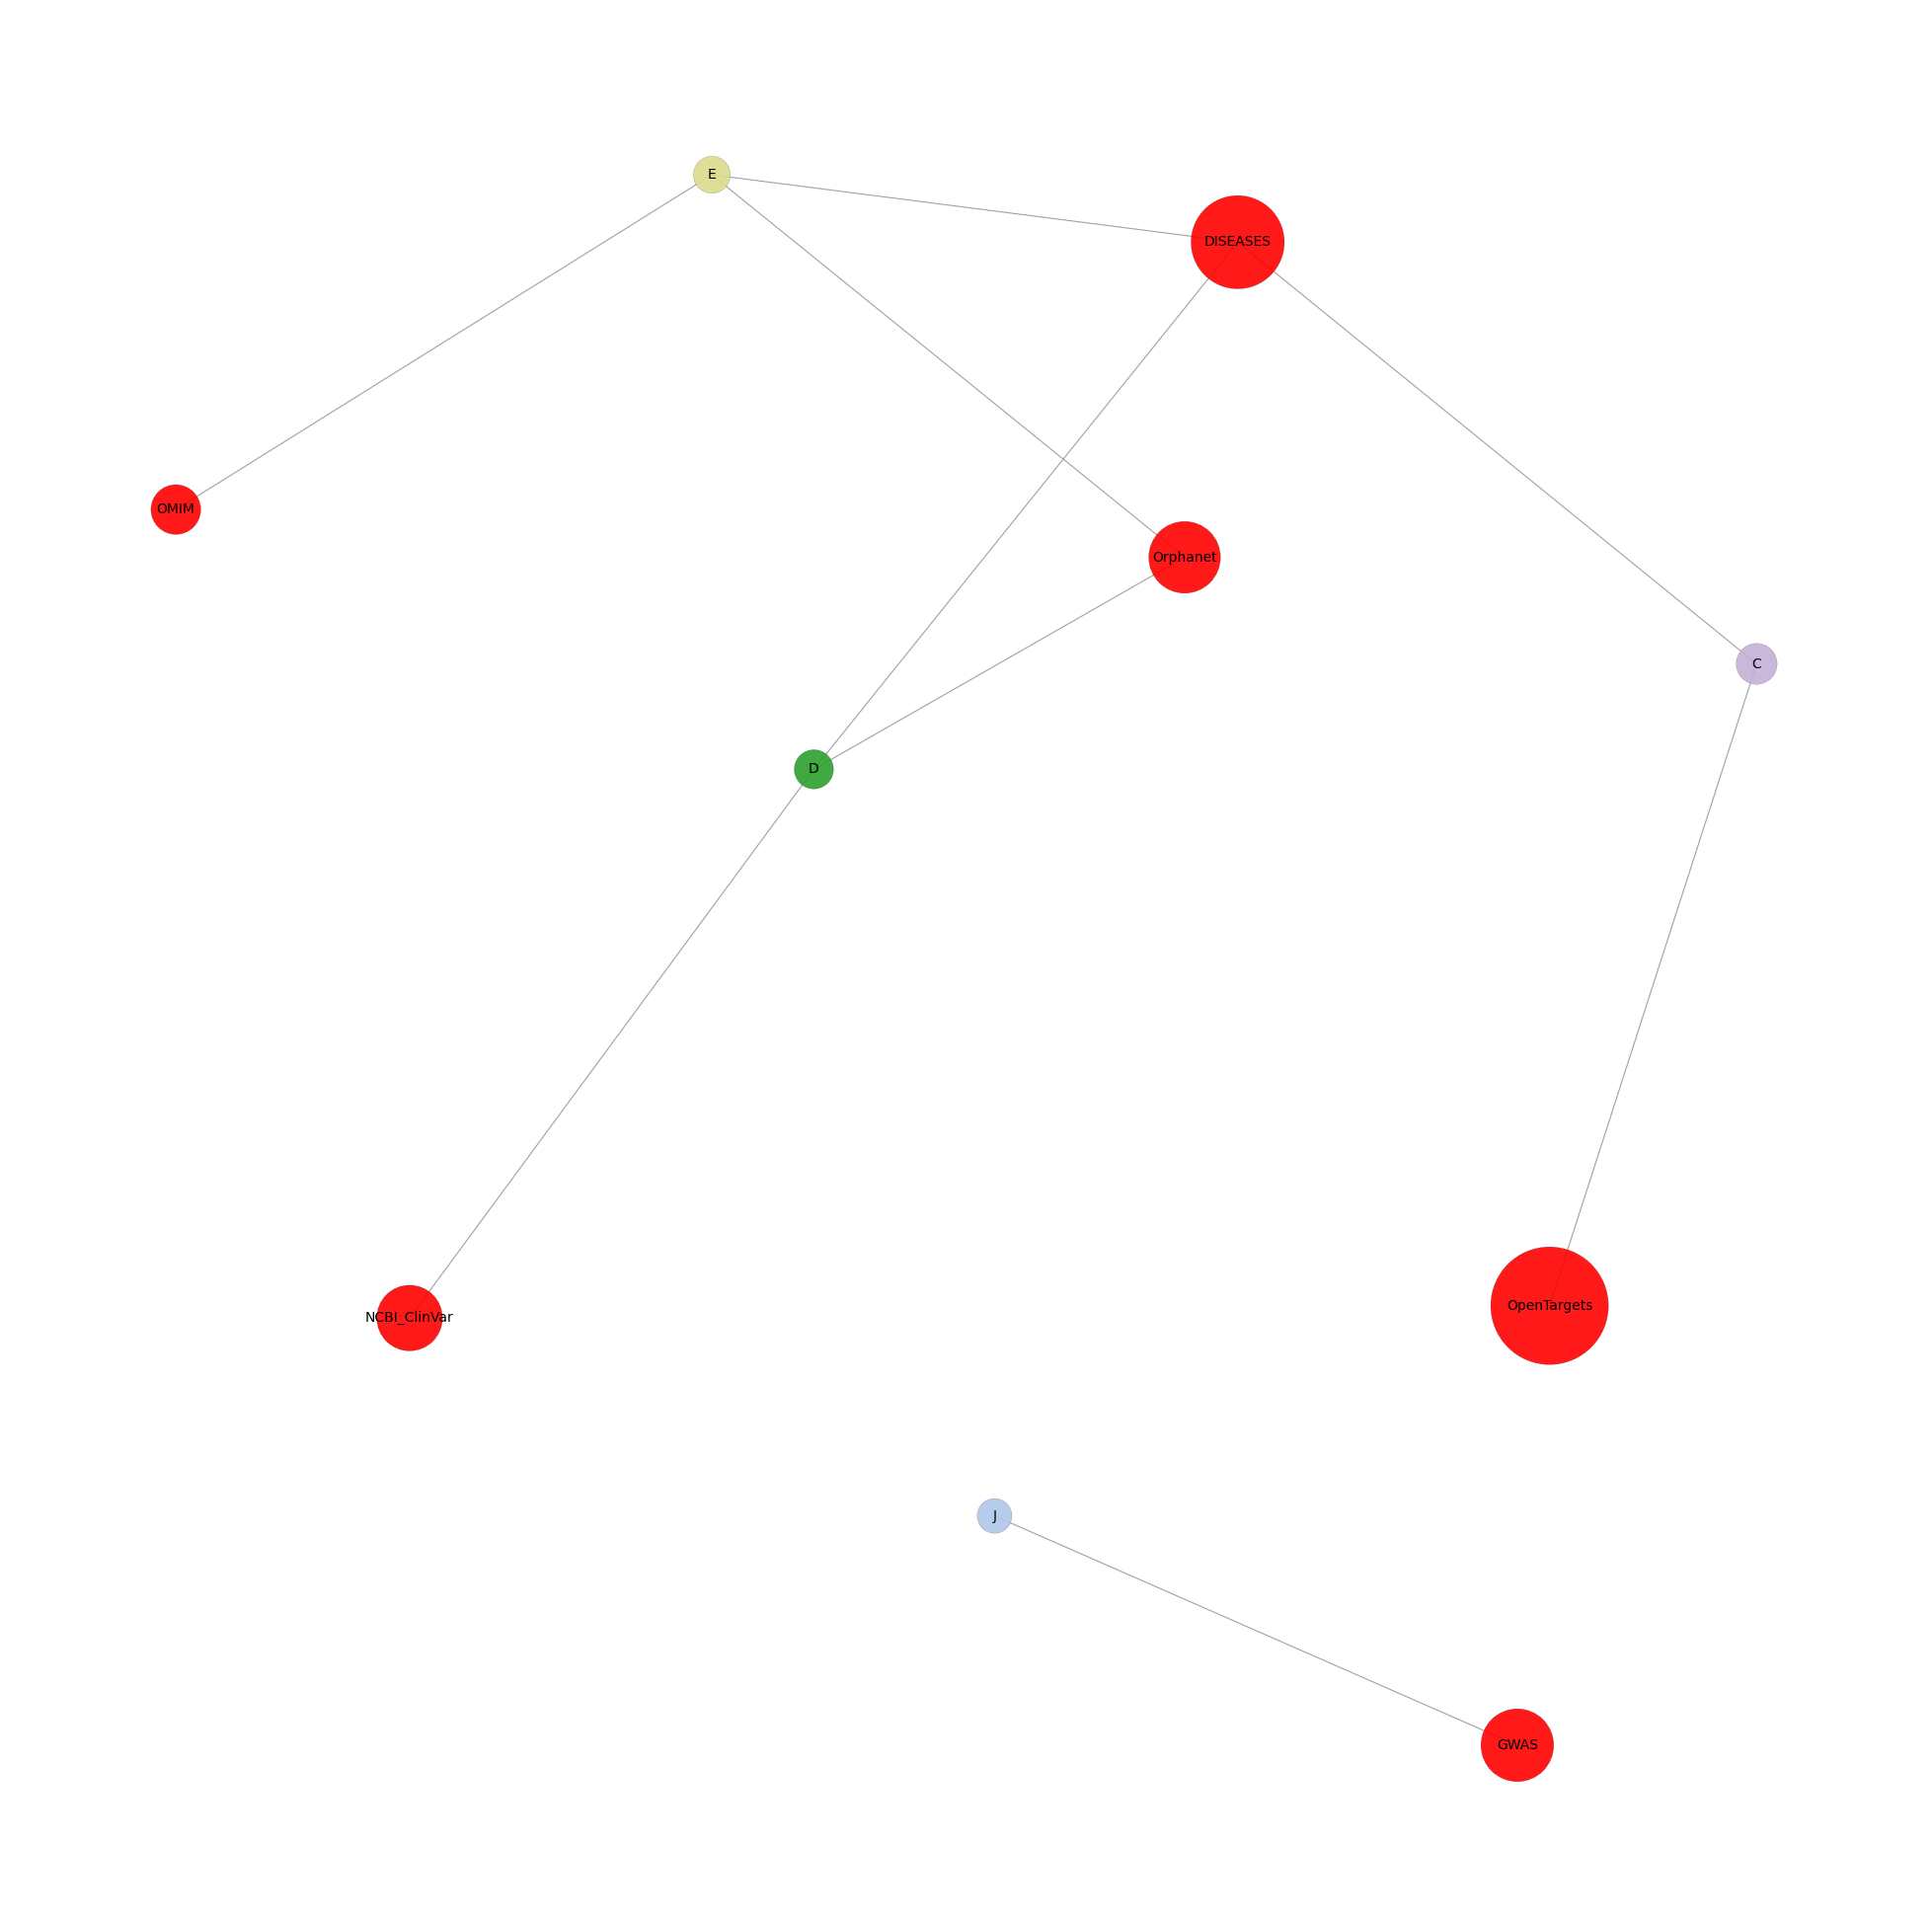

In [628]:
opacity_nodes = 0.9
node_edge_col = '#000000' 
node_linewidth = 0.1

#edge_opacity = 0.5
edge_width = 0.8
edge_color = '#A1A1A1' #'#6C6C6C' #'#d3d3d3'

color_list = []
node_size = []
for node in posG_sources_cat_icd_spring.keys():
    try:
        color_list.append(icd_cat_color_mapping[node])
        node_size.append(len(icd10_cat_dict[node])*10)
    except:
        color_list.append('red')
        node_size.append(len(list(sources_dict_cl[node].keys()))*10)
        


plt.figure(figsize=(25,25))
nx.draw_networkx_nodes(G_sources_cat_icd, 
                       posG_sources_cat_icd_spring,
                       edgecolors = node_edge_col, 
                       linewidths = node_linewidth, 
                       node_color = color_list, 
                       node_size = node_size, 
                       alpha = opacity_nodes)
widths = nx.get_edge_attributes(G_sources_cat_icd, 'weight')
max_width = max(widths.values())
min_width = min(widths.values())

nx.draw_networkx_edges(G_sources_cat_icd, posG_sources_cat_icd_spring,  width = edge_width, edge_color = edge_color)
plt.box(False)
nx.draw_networkx_labels(G_sources_cat_icd,pos=posG_sources_cat_icd_spring,font_size=10)
#plt.savefig('Figures/Fig1D.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()


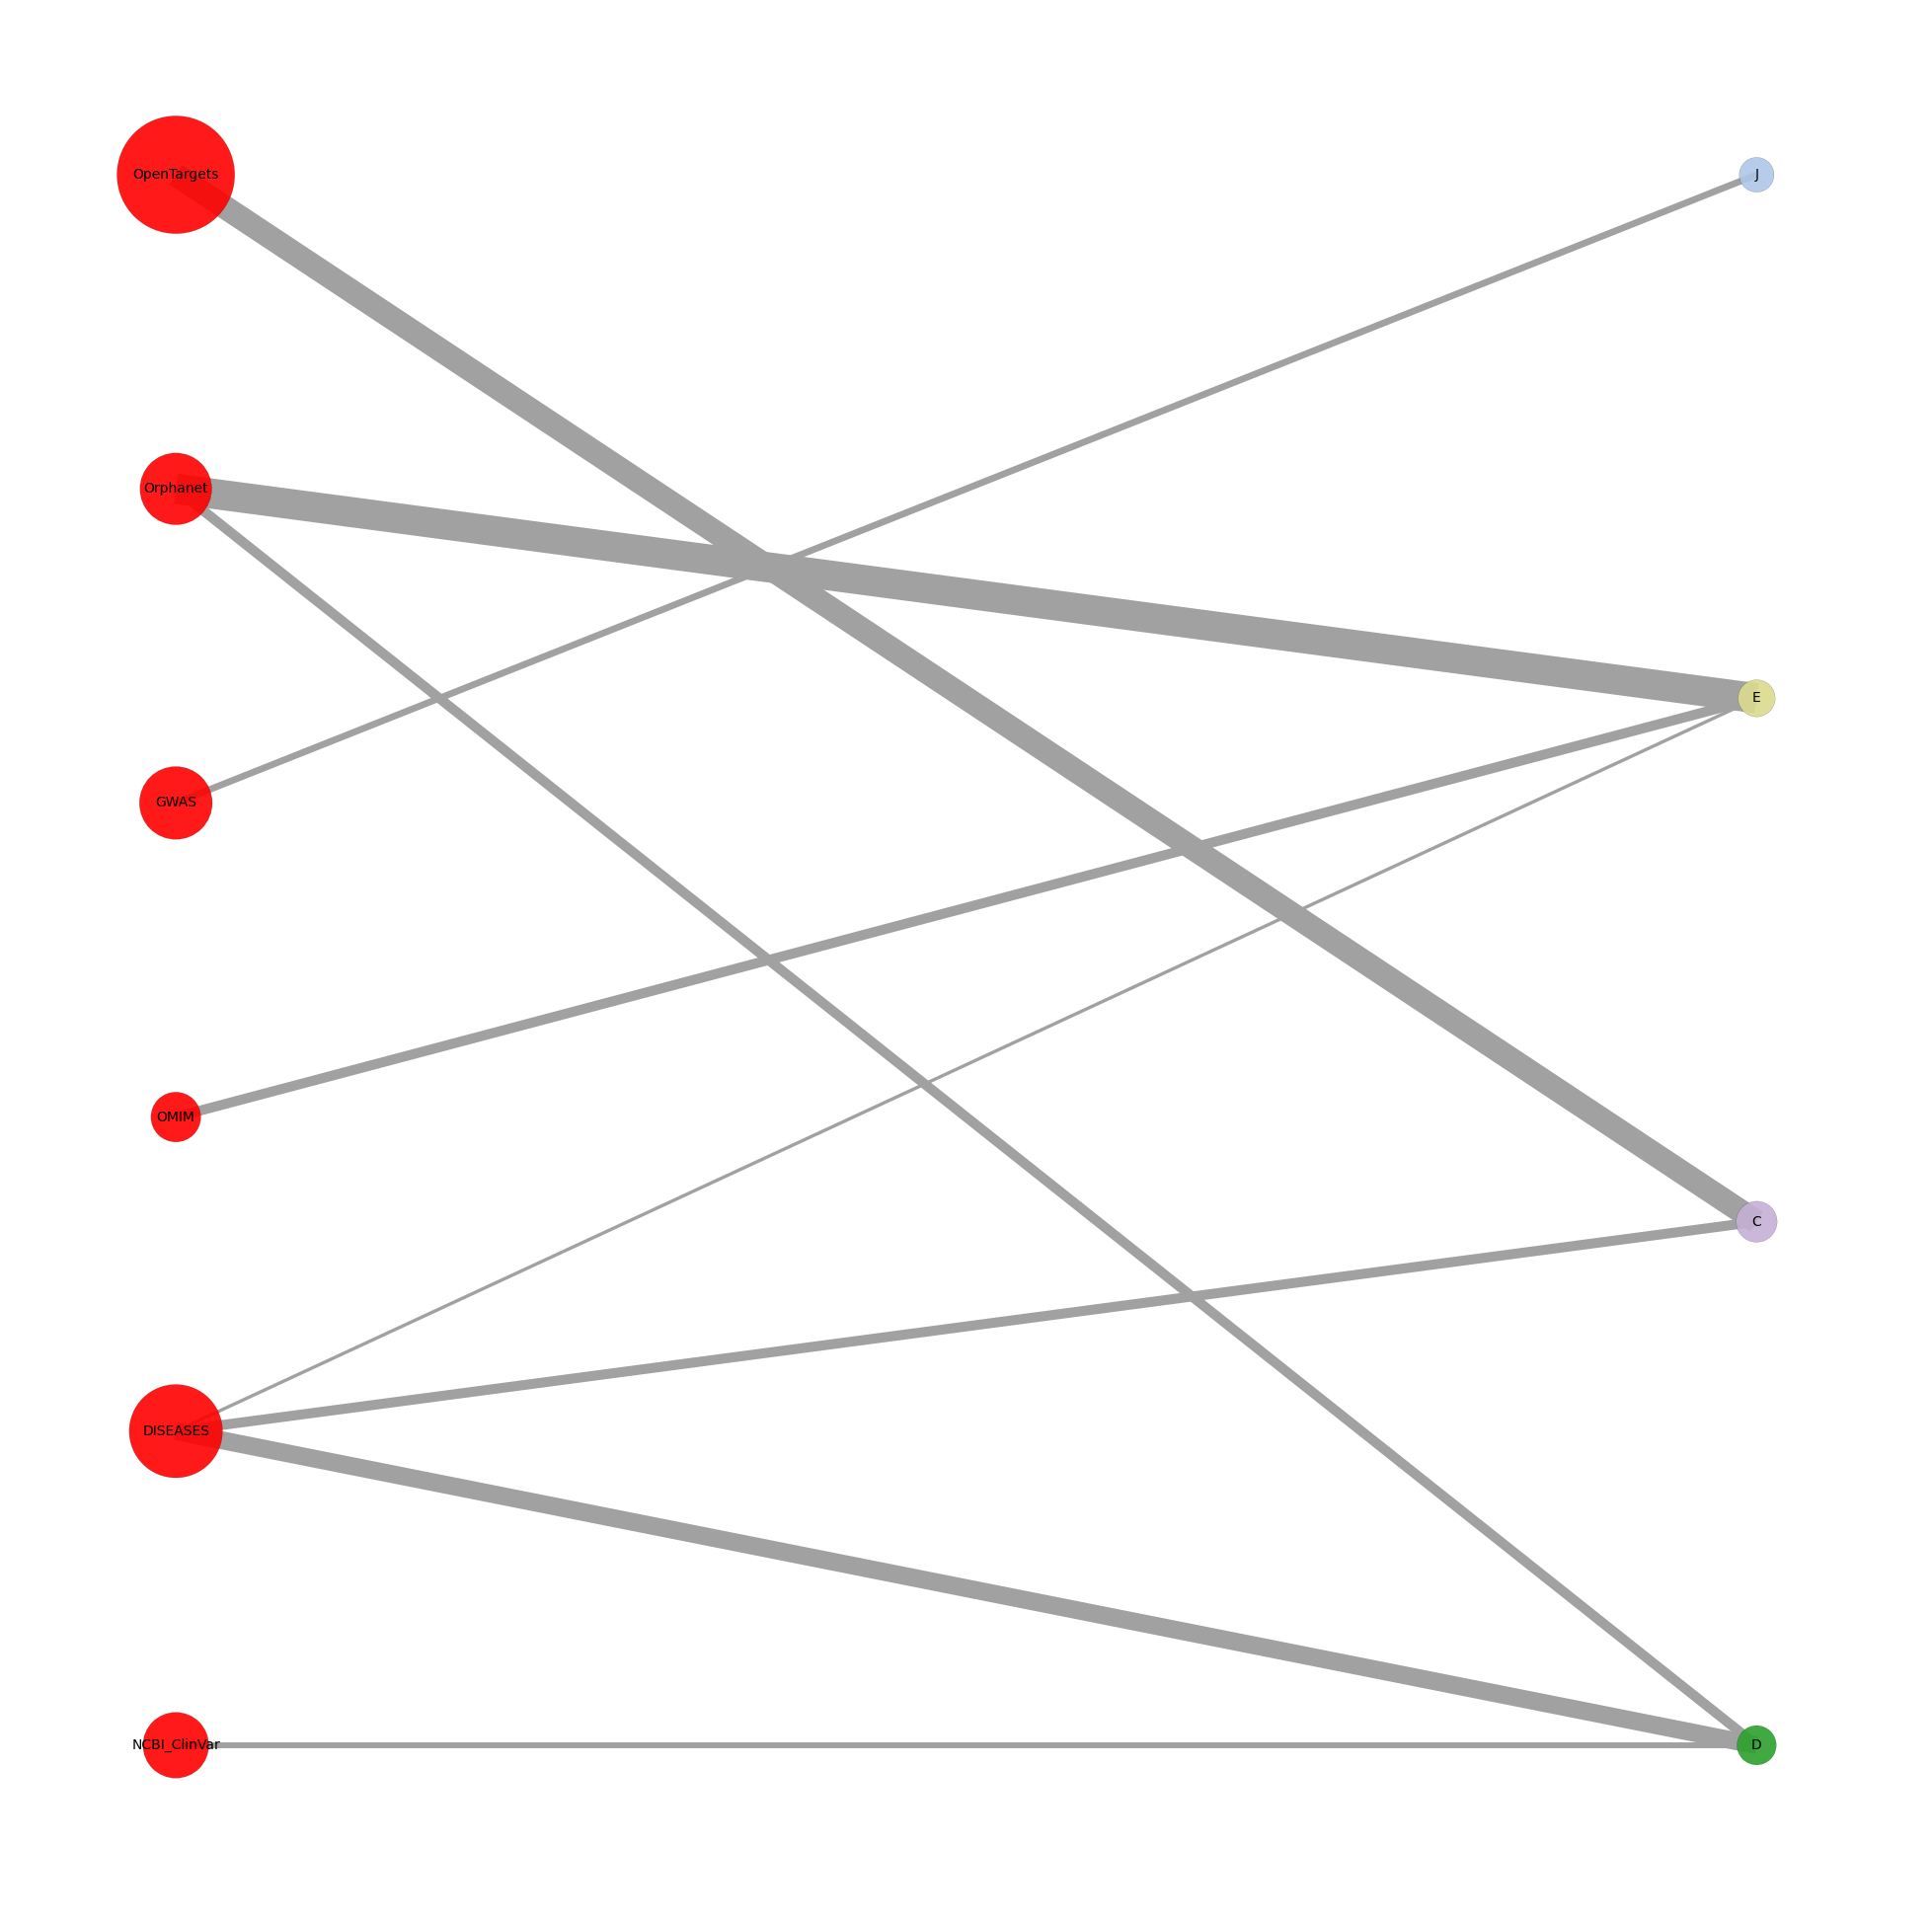

In [638]:
# Constants for visual appearance
opacity_nodes = 0.9
node_edge_col = '#000000' 
node_linewidth = 0.1
edge_width = 0.8
edge_color = '#A1A1A1'


# Create a bipartite graph
B = nx.Graph()

# Create node lists for bipartite sets
try_nodes = []
except_nodes = []

# Process nodes and classify them into two types
for node in posG_sources_cat_icd_spring.keys():
    try:
        # Nodes that fulfill the 'try' condition
        try_nodes.append(node)
        color = icd_cat_color_mapping[node]
        size = len(icd10_cat_dict[node]) * 10
    except:
        # Nodes that fall into 'except'
        except_nodes.append(node)
        color = 'red'
        size = len(list(sources_dict_cl[node].keys())) * 10
    
    # Add nodes with attributes to the bipartite graph
    B.add_node(node, color=color, size=size)

# Convert original graph's edges into edges in B
B.add_edges_from(G_sources_cat_icd.edges())

# Assign nodes to the bipartite sets: 0 for except_nodes (left), 1 for try_nodes (right)
B.add_nodes_from(except_nodes, bipartite=0)
B.add_nodes_from(try_nodes, bipartite=1)

# Use bipartite_layout for correct arrangement
pos = nx.bipartite_layout(B, except_nodes)  # Specify 'except_nodes' to be on the left

# Plot the bipartite graph
colors = [B.nodes[node]['color'] for node in B.nodes()]
sizes = [B.nodes[node]['size'] for node in B.nodes()]
edge_width_list = []
for e in B.edges():
    try:
        edge_width_list.append(0.1/sources_icd10cat_overlap_sigfdr_dict[e[0],e[1]])
    except:
        edge_width_list.append(0.1/sources_icd10cat_overlap_sigfdr_dict[e[1],e[0]])
    


plt.figure(figsize=(25, 25))
nx.draw_networkx_nodes(B, pos,
                       edgecolors=node_edge_col, 
                       linewidths=node_linewidth, 
                       node_color=colors, 
                       node_size=sizes,
                       alpha=opacity_nodes)

nx.draw_networkx_edges(B, pos, width=edge_width_list, edge_color=edge_color)

nx.draw_networkx_labels(B, pos=pos, font_size=10)

plt.box(False)
plt.savefig('Figures/Fig1E.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()